# How Culture Shapes Guest Perception
## A Cross-Cultural Analysis of 2.2 Million Airbnb London Reviews

---

**Authors:** AirBNB London Analysis Team  
**Date:** May 2026  
**Dataset:** Inside Airbnb — London (September 2025 scrape)  
**Environment:** Python 3.11 · PyTorch 2.6 (CUDA) · RTX 3050 GPU

---

### Abstract

London is one of the world's most visited cities, attracting guests from virtually every country and cultural background. This notebook investigates **whether reviewers from different linguistic and cultural backgrounds rate Airbnb listings systematically differently** — even when staying at the *exact same property*.

We analyse 2.2 million reviews spanning 15 years (2010–2025), applying language detection, GPU-accelerated multilingual sentiment analysis, and rigorous statistical testing to answer four research questions.

### Research Questions

| # | Question | Method |
|---|---------|--------|
| **RQ1** | Do reviewers writing in different languages rate listings systematically differently? | Kruskal-Wallis H-test across 7 rating dimensions |
| **RQ2** | Is there a measurable sentiment gap across cultures for the *same* listing? | Paired same-listing comparison with Wilcoxon signed-rank |
| **RQ3** | Which service aspects (cleanliness, location, value, etc.) do different cultures prioritise in their reviews? | Aspect frequency analysis + Chi-square test |
| **RQ4** | How does the host's country of origin correlate with the ratings they receive? | Host country extraction + group comparison |

### Methodology Pipeline

```
reviews.csv.gz (2.21M)  ──┐
                          ├── Merge on listing_id ──► Language Detection (langid) ──► Cultural Region Mapping
listings.csv (97K)      ──┘                                     │
                                                                ▼
scores.csv (2.1M)  ──────────────────────────────────► Rating Analysis by Language Group
                                                                │
                                                                ├──► Same-Listing Paired Comparison
                                                                ├──► GPU Multilingual Sentiment (BERT)
                                                                ├──► Aspect-Level Cultural Priorities
                                                                ├──► Host Country Impact Analysis
                                                                └──► Borough-Level Geographic Mapping
```

---
## 1. Environment Setup & Package Installation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import gzip
from pathlib import Path
from collections import Counter

from scipy import stats
from scipy.stats import kruskal, chi2_contingency, wilcoxon, mannwhitneyu
import scikit_posthocs as sp

import langid
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import torch
from transformers import pipeline
from tqdm import tqdm

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR = Path(r'data/data')
print(f'Data directory: {DATA_DIR.resolve()}')

PyTorch device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Data directory: C:\Users\windows\Downloads\AirBNB_London_Analysis\AirBNB_London_Analysis\data\data


---
## 2. Data Loading & Preprocessing

We load three core datasets and merge them into a single analytical frame:

- **reviews.csv.gz** — 2.1M individual reviews with `reviewer_name`, `comments`, and `date`
- **listings.csv.gz** — 97K listing profiles (full 79-column version) with `host_location`, review scores, property metadata
- **scores.csv** — 2.1M rows mapping each review to its listing-level rating breakdown

In [2]:
print('Loading reviews.csv.gz (2.1M rows)...')
reviews = pd.read_csv(DATA_DIR / 'reviews.csv.gz', compression='gzip',
                      parse_dates=['date'])
print(f'  Reviews loaded: {len(reviews):,} rows, {reviews.shape[1]} columns')

print('Loading listings.csv.gz (97K rows, full 79-column version)...')
listings = pd.read_csv(DATA_DIR / 'listings.csv.gz', compression='gzip')
print(f'  Listings loaded: {len(listings):,} rows, {listings.shape[1]} columns')

print('Loading scores.csv (2.1M rows)...')
scores = pd.read_csv(DATA_DIR / 'scores.csv')
print(f'  Scores loaded: {len(scores):,} rows, {scores.shape[1]} columns')

print('Loading neighbourhoods.geojson...')
with open(DATA_DIR / 'neighbourhoods.geojson', 'r', encoding='utf-8') as f:
    geo_data = json.load(f)
print(f'  GeoJSON loaded: {len(geo_data["features"])} borough polygons')

Loading reviews.csv.gz (2.1M rows)...


  Reviews loaded: 2,097,996 rows, 6 columns
Loading listings.csv.gz (97K rows, full 79-column version)...


  Listings loaded: 96,871 rows, 79 columns
Loading scores.csv (2.1M rows)...


  Scores loaded: 2,097,996 rows, 9 columns
Loading neighbourhoods.geojson...
  GeoJSON loaded: 33 borough polygons


In [3]:
print('--- Reviews Schema ---')
print(reviews.dtypes)
print(f'\nDate range: {reviews["date"].min()} to {reviews["date"].max()}')
print(f'Missing comments: {reviews["comments"].isna().sum():,} ({reviews["comments"].isna().mean()*100:.2f}%)')
print(f'Unique reviewers: {reviews["reviewer_id"].nunique():,}')
print(f'Unique listings:  {reviews["listing_id"].nunique():,}')

--- Reviews Schema ---
listing_id                int64
id                        int64
date             datetime64[us]
reviewer_id               int64
reviewer_name               str
comments                    str
dtype: object

Date range: 2009-12-21 00:00:00 to 2025-09-17 00:00:00


Missing comments: 201 (0.01%)


Unique reviewers: 1,768,660
Unique listings:  72,749


In [4]:
LISTING_COLS = [
    'id', 'host_id', 'host_name', 'host_location', 'host_is_superhost',
    'host_since', 'neighbourhood_cleansed', 'latitude', 'longitude',
    'property_type', 'room_type', 'accommodates', 'price',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'number_of_reviews'
]

listings_slim = listings[LISTING_COLS].copy()
listings_slim.rename(columns={'id': 'listing_id'}, inplace=True)

df = reviews.merge(listings_slim, on='listing_id', how='left')
print(f'Merged dataset: {len(df):,} rows x {df.shape[1]} columns')
print(f'Listings matched: {df["host_id"].notna().sum():,} / {len(df):,} ({df["host_id"].notna().mean()*100:.1f}%)')

df = df.dropna(subset=['comments'])
print(f'After dropping null comments: {len(df):,} rows')

df.head(3)

Merged dataset: 2,097,996 rows x 26 columns
Listings matched: 2,097,996 / 2,097,996 (100.0%)


After dropping null comments: 2,097,795 rows


,listing_id,id,date,reviewer_id,reviewer_name,comments,host_id,host_name,host_location,host_is_superhost,...,accommodates,price,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,number_of_reviews
0,13913,80770,2010-08-18,177109,Michael,My girlfriend and I hadn't known Alina before ...,54730,Alina,"London, United Kingdom",t,...,1,$70.00,4.85,4.8,4.8,4.81,4.87,4.78,4.78,55
1,13913,367568,2011-07-11,19835707,Mathias,Alina was a really good host. The flat is clea...,54730,Alina,"London, United Kingdom",t,...,1,$70.00,4.85,4.8,4.8,4.81,4.87,4.78,4.78,55
2,13913,529579,2011-09-13,1110304,Kristin,Alina is an amazing host. She made me feel rig...,54730,Alina,"London, United Kingdom",t,...,1,$70.00,4.85,4.8,4.8,4.81,4.87,4.78,4.78,55


---
## 3. Language Detection Pipeline

Since Airbnb does not expose reviewer nationality, we use **language detection** on the review text as a cultural proxy. The `langid` library is chosen for its speed (~10K classifications/second) and reliability across 97 languages.

After detection, we map each ISO 639-1 language code to a human-readable language name and a broader **cultural region** (e.g., Western Europe, East Asia, Latin America) for aggregated analysis.

In [5]:
LANG_NAME = {
    'en': 'English',    'fr': 'French',     'de': 'German',     'es': 'Spanish',
    'it': 'Italian',    'pt': 'Portuguese', 'nl': 'Dutch',      'pl': 'Polish',
    'ru': 'Russian',    'zh': 'Chinese',    'ja': 'Japanese',   'ko': 'Korean',
    'ar': 'Arabic',     'tr': 'Turkish',    'sv': 'Swedish',    'da': 'Danish',
    'no': 'Norwegian',  'fi': 'Finnish',    'el': 'Greek',      'cs': 'Czech',
    'ro': 'Romanian',   'hu': 'Hungarian',  'th': 'Thai',       'he': 'Hebrew',
    'hi': 'Hindi',      'id': 'Indonesian',
}

CULTURAL_REGION = {
    'en': 'Anglophone',     'fr': 'Western Europe',  'de': 'Western Europe',
    'es': 'Latin/Iberian',  'it': 'Western Europe',  'pt': 'Latin/Iberian',
    'nl': 'Western Europe', 'pl': 'Eastern Europe',  'ru': 'Eastern Europe',
    'zh': 'East Asia',      'ja': 'East Asia',       'ko': 'East Asia',
    'ar': 'Middle East',    'tr': 'Middle East',     'sv': 'Scandinavia',
    'da': 'Scandinavia',    'no': 'Scandinavia',     'fi': 'Scandinavia',
    'el': 'Southern Europe','cs': 'Eastern Europe',  'ro': 'Eastern Europe',
    'hu': 'Eastern Europe', 'th': 'Southeast Asia',  'he': 'Middle East',
    'hi': 'South Asia',     'id': 'Southeast Asia',
}

TARGET_LANGS = list(LANG_NAME.keys())
langid.set_languages(TARGET_LANGS)

def detect_language(text):
    try:
        lang, _ = langid.classify(str(text))
        return lang
    except:
        return 'unknown'

print(f'Running language detection on {len(df):,} reviews (~25 min)...')
print(f'Using langid restricted to {len(TARGET_LANGS)} target languages for speed')
tqdm.pandas(desc='Language detection')
df['lang_code'] = df['comments'].progress_apply(detect_language)

df['language'] = df['lang_code'].map(LANG_NAME).fillna('Other')
df['cultural_region'] = df['lang_code'].map(CULTURAL_REGION).fillna('Other')

print(f'\nLanguage detection complete.')
print(f'Languages found: {df["lang_code"].nunique()}')

Running language detection on 2,097,795 reviews (~25 min)...
Using langid restricted to 26 target languages for speed


Language detection:   0%|          | 0/2097795 [00:00<?, ?it/s]

Language detection:   0%|          | 1/2097795 [00:01<708:36:32,  1.22s/it]

Language detection:   0%|          | 128/2097795 [00:01<4:23:17, 132.78it/s]

Language detection:   0%|          | 277/2097795 [00:01<1:54:49, 304.46it/s]

...

Language detection: 100%|█████████▉| 2097348/2097795 [26:19<00:00, 1532.29it/s]

Language detection: 100%|█████████▉| 2097502/2097795 [26:19<00:00, 1528.22it/s]

Language detection: 100%|█████████▉| 2097660/2097795 [26:19<00:00, 1543.21it/s]

Language detection: 100%|██████████| 2097795/2097795 [26:21<00:00, 1326.72it/s]


Language detection complete.
Languages found: 26


In [6]:
lang_counts = df['language'].value_counts()
print('=== Top 20 Languages by Review Count ===\n')
for lang, count in lang_counts.head(20).items():
    pct = count / len(df) * 100
    print(f'  {lang:<15} {count:>10,}  ({pct:5.2f}%)')

print(f'\n  {"Other (combined)":<15} {lang_counts.iloc[20:].sum():>10,}  ({lang_counts.iloc[20:].sum()/len(df)*100:5.2f}%)')
print(f'\n  {"TOTAL":<15} {len(df):>10,}')

=== Top 20 Languages by Review Count ===

  English          1,722,987  (82.13%)
  French             116,389  ( 5.55%)
  Spanish             67,264  ( 3.21%)
  German              55,725  ( 2.66%)
  Italian             28,495  ( 1.36%)
  Chinese             23,725  ( 1.13%)
  Korean              16,375  ( 0.78%)
  Portuguese          16,260  ( 0.78%)
  Dutch               14,321  ( 0.68%)
  Japanese             5,892  ( 0.28%)
  Polish               4,219  ( 0.20%)
  Danish               3,755  ( 0.18%)
  Czech                3,280  ( 0.16%)
  Swedish              3,042  ( 0.15%)
  Norwegian            2,990  ( 0.14%)
  Turkish              2,880  ( 0.14%)
  Arabic               2,576  ( 0.12%)
  Russian              1,990  ( 0.09%)
  Finnish              1,187  ( 0.06%)
  Hebrew               1,169  ( 0.06%)

  Other (combined)      3,274  ( 0.16%)

  TOTAL            2,097,795


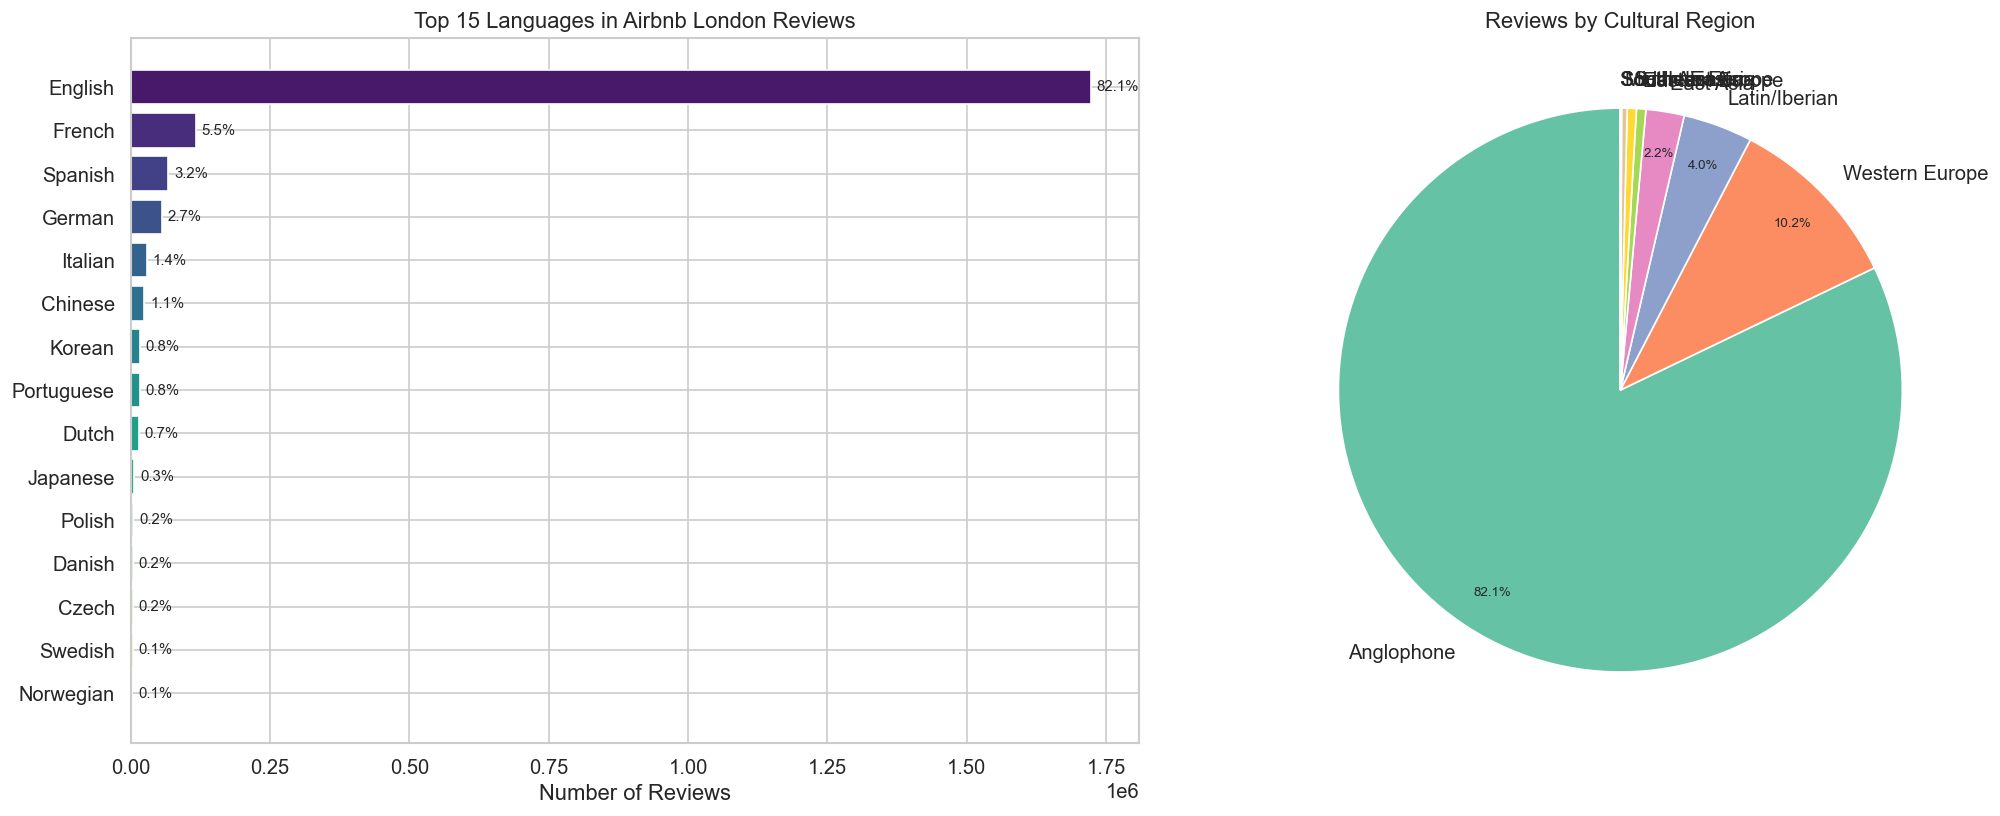

Saved: lang_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_langs = lang_counts.head(15)
colors = sns.color_palette('viridis', len(top_langs))
axes[0].barh(top_langs.index[::-1], top_langs.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Number of Reviews')
axes[0].set_title('Top 15 Languages in Airbnb London Reviews')
for i, (val, lang) in enumerate(zip(top_langs.values[::-1], top_langs.index[::-1])):
    axes[0].text(val + len(df)*0.005, i, f'{val/len(df)*100:.1f}%', va='center', fontsize=9)

region_counts = df['cultural_region'].value_counts()
region_colors = sns.color_palette('Set2', len(region_counts))
wedges, texts, autotexts = axes[1].pie(
    region_counts.values, labels=region_counts.index,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    colors=region_colors, startangle=90, pctdistance=0.85
)
axes[1].set_title('Reviews by Cultural Region')
for text in autotexts:
    text.set_fontsize(8)

plt.tight_layout()
plt.savefig('lang_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lang_distribution.png')

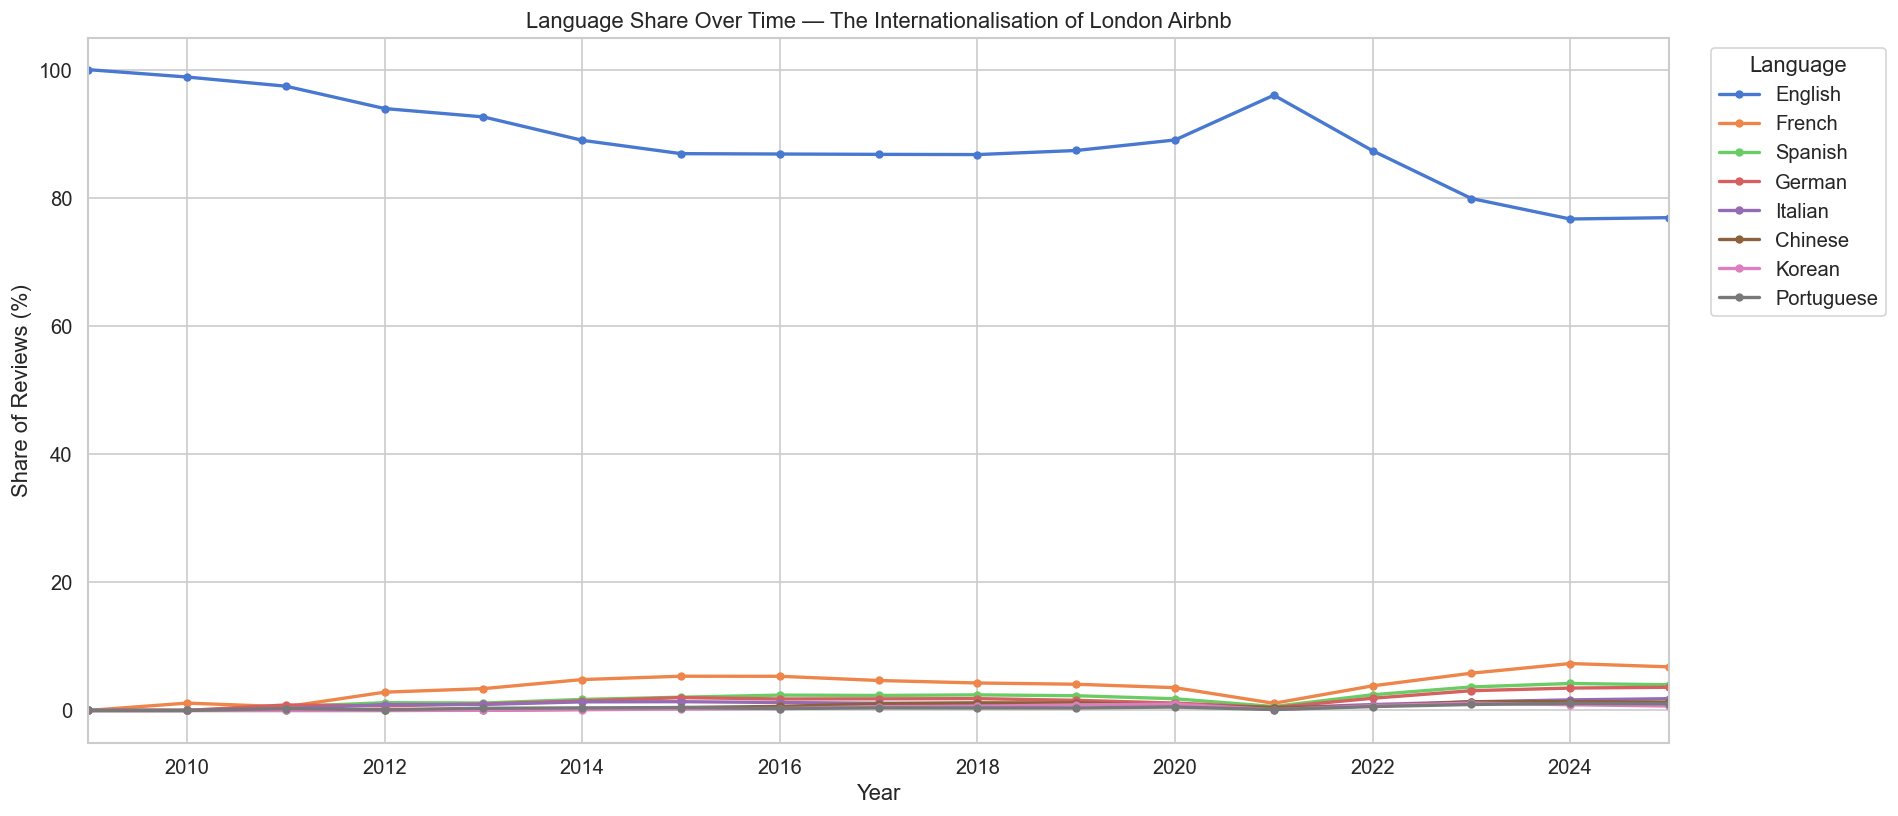

In [8]:
df['year'] = df['date'].dt.year
yearly_lang = df.groupby(['year', 'language']).size().unstack(fill_value=0)

top8 = lang_counts.head(8).index.tolist()
yearly_pct = yearly_lang[top8].div(yearly_lang.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 7))
yearly_pct.plot(ax=ax, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Share of Reviews (%)')
ax.set_title('Language Share Over Time — The Internationalisation of London Airbnb')
ax.legend(title='Language', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlim(yearly_pct.index.min(), yearly_pct.index.max())
plt.tight_layout()
plt.savefig('language_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. GPU-Powered Multilingual Sentiment Analysis

Traditional sentiment tools like VADER only work reliably on English text. Since our dataset contains substantial non-English reviews, we use a **multilingual BERT model** (`nlptown/bert-base-multilingual-uncased-sentiment`) that predicts star ratings (1–5) across English, French, German, Spanish, Dutch, and Italian.

This model runs on the RTX 3050 GPU with FP16 precision for efficiency. We process a **stratified sample of 50,000 reviews** balanced across the top 8 language groups to keep inference time reasonable (~15 minutes).

In [9]:
SAMPLE_SIZE = 50_000
top8_langs = df['language'].value_counts().head(8).index.tolist()
per_lang = SAMPLE_SIZE // len(top8_langs)

samples = []
for lang in top8_langs:
    pool = df[df['language'] == lang]
    n = min(per_lang, len(pool))
    samples.append(pool.sample(n=n, random_state=42))

sentiment_sample = pd.concat(samples, ignore_index=True)
print(f'Sentiment sample: {len(sentiment_sample):,} reviews across {len(top8_langs)} languages')
print(sentiment_sample['language'].value_counts().to_string())

Sentiment sample: 50,000 reviews across 8 languages
language
English       6250
French        6250
Spanish       6250
German        6250
Italian       6250
Chinese       6250
Korean        6250
Portuguese    6250


In [10]:
print(f'Loading multilingual sentiment model on {DEVICE}...')
sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    device=0 if DEVICE == 'cuda' else -1,
    dtype=torch.float16,
    truncation=True,
    max_length=512
)

def predict_stars_batch(texts, batch_size=64):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='GPU sentiment'):
        batch = texts[i:i+batch_size]
        batch = [str(t)[:512] for t in batch]
        preds = sentiment_pipe(batch, batch_size=batch_size)
        results.extend([int(p['label'][0]) for p in preds])
    return results

texts = sentiment_sample['comments'].tolist()
sentiment_sample['bert_stars'] = predict_stars_batch(texts)

print(f'\\nSentiment prediction complete.')
print(f'Mean predicted stars: {sentiment_sample["bert_stars"].mean():.2f}')
print(sentiment_sample['bert_stars'].value_counts().sort_index())

Loading multilingual sentiment model on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   2%|▏         | 5/201 [00:00<00:34,  5.68it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 224.54it/s]

GPU sentiment:   0%|          | 0/782 [00:00<?, ?it/s]

...

GPU sentiment: 100%|█████████▉| 779/782 [03:45<00:00,  4.55it/s]

GPU sentiment: 100%|█████████▉| 780/782 [03:45<00:00,  4.57it/s]

GPU sentiment: 100%|█████████▉| 781/782 [03:45<00:00,  4.55it/s]

GPU sentiment: 100%|██████████| 782/782 [03:45<00:00,  3.47it/s]

\nSentiment prediction complete.
Mean predicted stars: 4.37
bert_stars
1      810
2     2281
3     3999
4    13577
5    29333
Name: count, dtype: int64


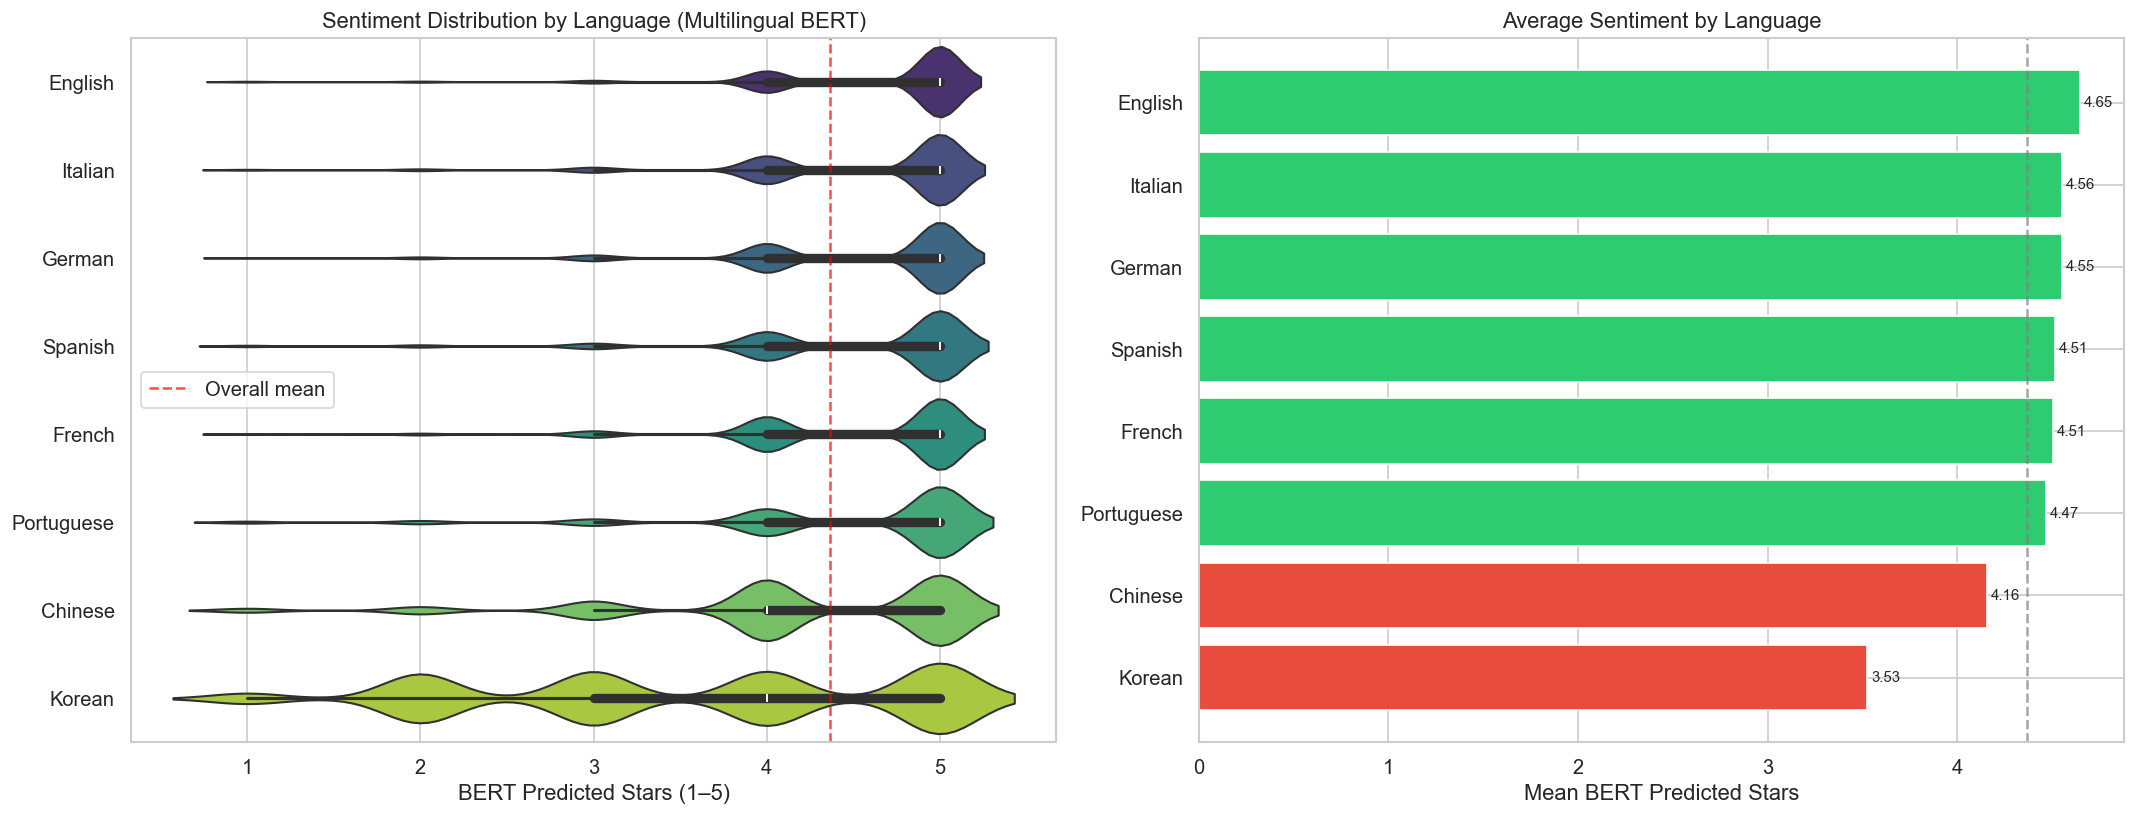

GPU memory released.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

lang_order = sentiment_sample.groupby('language')['bert_stars'].mean().sort_values(ascending=False).index
sns.violinplot(data=sentiment_sample, y='language', x='bert_stars',
               order=lang_order, palette='viridis', inner='box', ax=axes[0])
axes[0].set_xlabel('BERT Predicted Stars (1–5)')
axes[0].set_ylabel('')
axes[0].set_title('Sentiment Distribution by Language (Multilingual BERT)')
axes[0].axvline(sentiment_sample['bert_stars'].mean(), color='red',
                linestyle='--', alpha=0.7, label='Overall mean')
axes[0].legend()

mean_stars = sentiment_sample.groupby('language')['bert_stars'].mean().reindex(lang_order)
colors = ['#2ecc71' if v >= sentiment_sample['bert_stars'].mean() else '#e74c3c' for v in mean_stars]
axes[1].barh(mean_stars.index[::-1], mean_stars.values[::-1], color=colors[::-1])
axes[1].set_xlabel('Mean BERT Predicted Stars')
axes[1].set_title('Average Sentiment by Language')
axes[1].axvline(sentiment_sample['bert_stars'].mean(), color='grey', linestyle='--', alpha=0.7)
for i, (val, lang) in enumerate(zip(mean_stars.values[::-1], mean_stars.index[::-1])):
    axes[1].text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('sentiment_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

del sentiment_pipe
torch.cuda.empty_cache()
print('GPU memory released.')

---
## 5. Rating Patterns by Reviewer Language

Airbnb listings have **seven rating dimensions**: overall rating, accuracy, cleanliness, check-in, communication, location, and value. These scores are at the *listing* level (aggregated from all reviews), so we examine whether listings disproportionately reviewed by certain language groups carry systematically different scores.

We use the **Kruskal-Wallis H-test** (non-parametric one-way ANOVA) because rating distributions are heavily left-skewed, followed by **Dunn's post-hoc test** for pairwise comparisons with Bonferroni correction.

In [12]:
SCORE_COLS = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]
SCORE_LABELS = ['Rating', 'Accuracy', 'Cleanliness', 'Check-in',
                'Communication', 'Location', 'Value']

analysis_langs = df['language'].value_counts().head(10).index.tolist()
df_rated = df[df['language'].isin(analysis_langs)].dropna(subset=SCORE_COLS)
print(f'Reviews with all 7 scores from top 10 languages: {len(df_rated):,}')

mean_scores = df_rated.groupby('language')[SCORE_COLS].mean()
mean_scores.columns = SCORE_LABELS
mean_scores = mean_scores.reindex(analysis_langs)

print('\n=== Mean Scores by Language ===')
print(mean_scores.round(3).to_string())

Reviews with all 7 scores from top 10 languages: 2,067,385

=== Mean Scores by Language ===
            Rating  Accuracy  Cleanliness  Check-in  Communication  Location  Value
language                                                                           
English      4.762     4.806        4.743     4.859          4.876     4.782  4.703
French       4.705     4.761        4.680     4.839          4.856     4.745  4.646
Spanish      4.679     4.740        4.655     4.822          4.837     4.731  4.633
German       4.737     4.785        4.715     4.850          4.867     4.737  4.678
Italian      4.705     4.761        4.684     4.836          4.850     4.744  4.650
Chinese      4.755     4.798        4.742     4.851          4.872     4.779  4.696
Korean       4.773     4.819        4.752     4.870          4.887     4.788  4.728
Portuguese   4.699     4.751        4.679     4.828          4.843     4.727  4.648
Dutch        4.741     4.789        4.723     4.848          4.868  

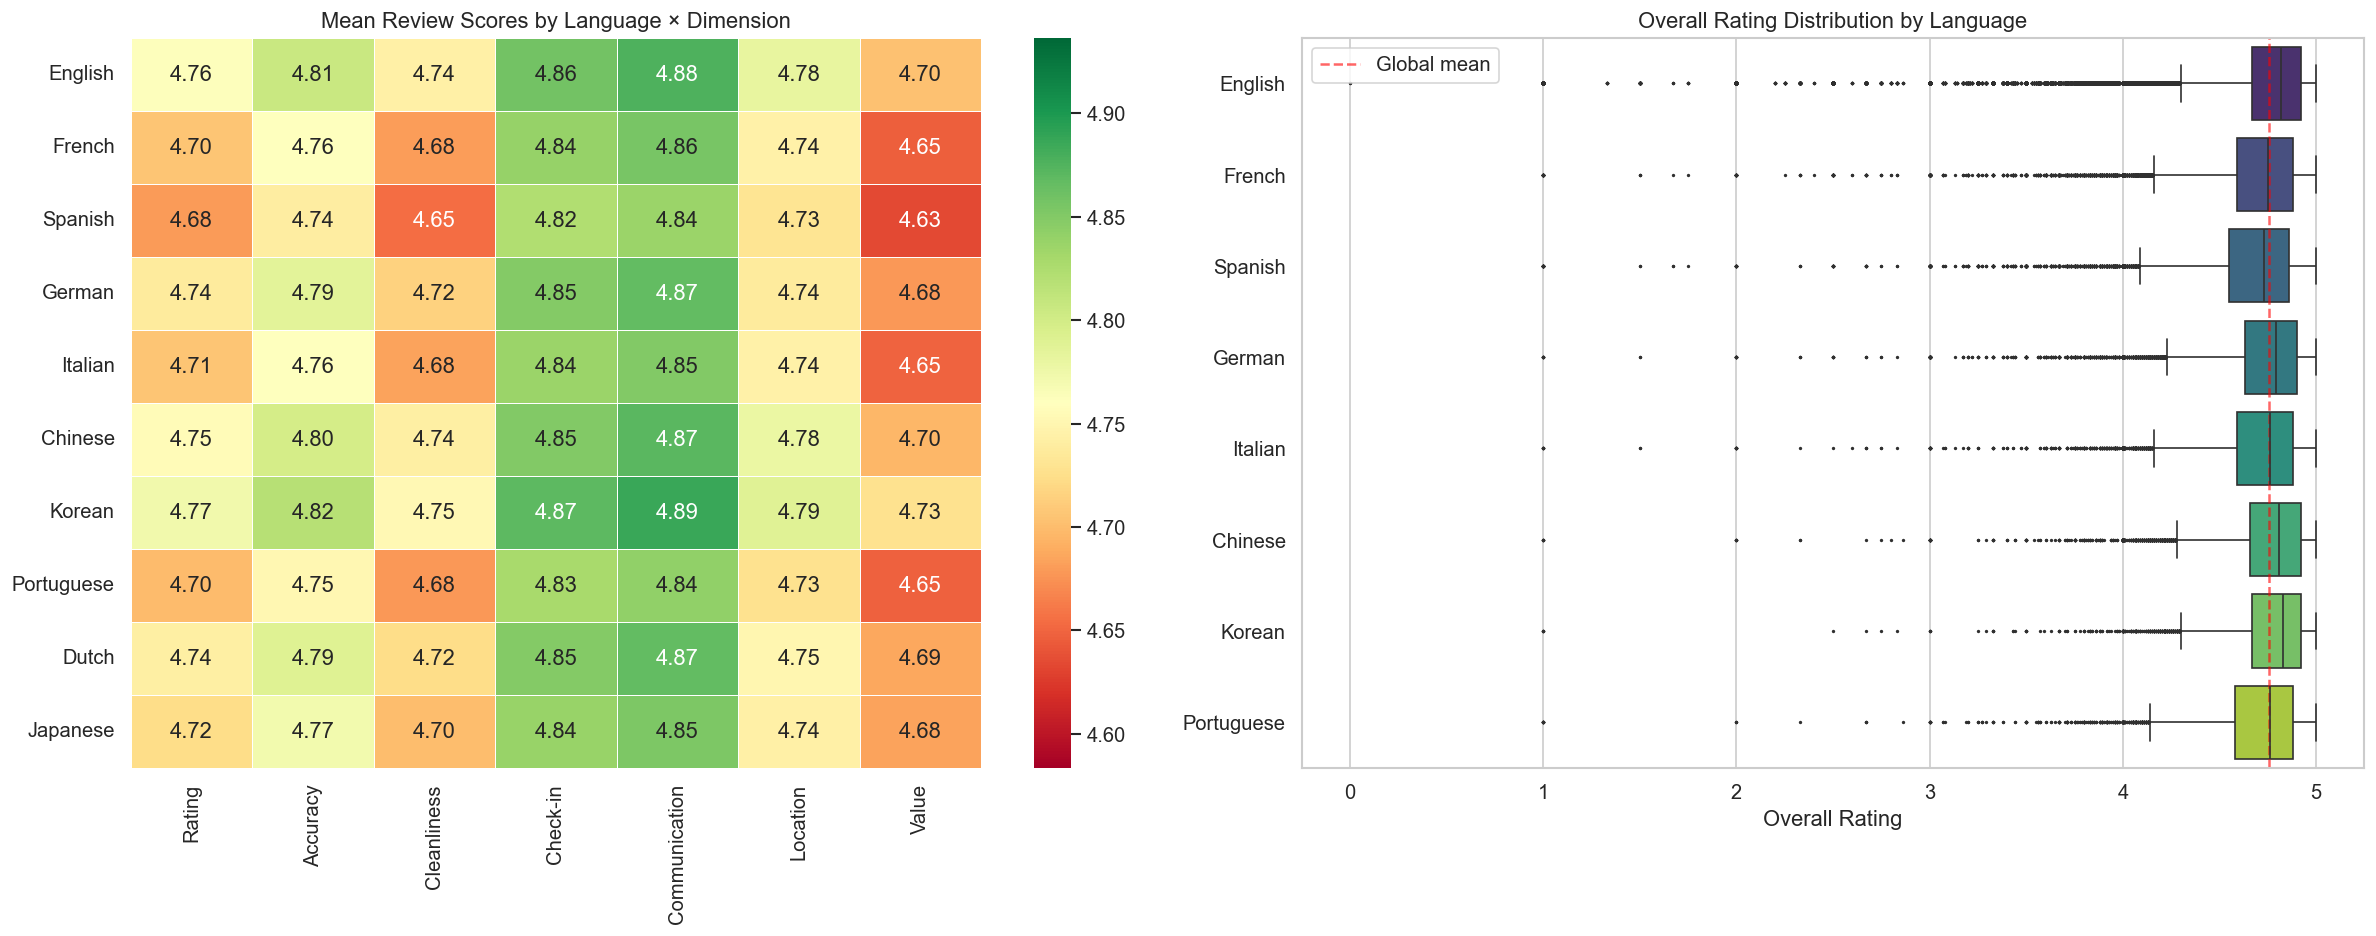

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(mean_scores, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=mean_scores.values.min() - 0.05,
            vmax=mean_scores.values.max() + 0.05, ax=axes[0])
axes[0].set_title('Mean Review Scores by Language × Dimension')
axes[0].set_ylabel('')
axes[0].set_xlabel('')

sns.boxplot(data=df_rated[df_rated['language'].isin(analysis_langs[:8])],
            y='language', x='review_scores_rating',
            order=mean_scores.index[:8],
            palette='viridis', ax=axes[1], fliersize=1)
axes[1].set_xlabel('Overall Rating')
axes[1].set_ylabel('')
axes[1].set_title('Overall Rating Distribution by Language')
axes[1].axvline(df_rated['review_scores_rating'].mean(), color='red',
                linestyle='--', alpha=0.6, label='Global mean')
axes[1].legend()

plt.tight_layout()
plt.savefig('rating_by_language.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print('=== Kruskal-Wallis H-Test: Rating Differences Across Languages ===\n')
kw_results = []
for col, label in zip(SCORE_COLS, SCORE_LABELS):
    groups = [g[col].dropna().values for _, g in df_rated.groupby('language')]
    stat, pval = kruskal(*groups)
    kw_results.append({'Dimension': label, 'H-statistic': stat, 'p-value': pval,
                       'Significant (p<0.001)': 'Yes' if pval < 0.001 else 'No'})

kw_df = pd.DataFrame(kw_results)
print(kw_df.to_string(index=False))

print('\n=== Dunn\'s Post-Hoc Test (Overall Rating) — Bonferroni corrected ===\n')
dunn = sp.posthoc_dunn(
    df_rated, val_col='review_scores_rating', group_col='language',
    p_adjust='bonferroni'
)
sig_pairs = []
for i in range(len(dunn)):
    for j in range(i+1, len(dunn)):
        if dunn.iloc[i, j] < 0.001:
            sig_pairs.append((dunn.index[i], dunn.columns[j], dunn.iloc[i, j]))

print(f'Significant pairwise differences (p < 0.001): {len(sig_pairs)}')
for l1, l2, p in sorted(sig_pairs, key=lambda x: x[2])[:15]:
    print(f'  {l1:<12} vs {l2:<12}  p = {p:.2e}')

=== Kruskal-Wallis H-Test: Rating Differences Across Languages ===



    Dimension  H-statistic  p-value Significant (p<0.001)
       Rating 21294.548598      0.0                   Yes
     Accuracy 19609.154930      0.0                   Yes
  Cleanliness 19682.277317      0.0                   Yes
     Check-in 10667.954847      0.0                   Yes
Communication 11347.230623      0.0                   Yes
     Location 13940.705662      0.0                   Yes
        Value 18548.933778      0.0                   Yes

=== Dunn's Post-Hoc Test (Overall Rating) — Bonferroni corrected ===



Significant pairwise differences (p < 0.001): 39
  Chinese      vs Spanish       p = 0.00e+00
  English      vs French        p = 0.00e+00
  English      vs Italian       p = 0.00e+00
  English      vs Spanish       p = 0.00e+00
  French       vs Korean        p = 0.00e+00
  German       vs Spanish       p = 0.00e+00
  Korean       vs Spanish       p = 0.00e+00
  English      vs Portuguese    p = 4.49e-305
  Chinese      vs French        p = 6.34e-299
  Italian      vs Korean        p = 3.62e-223
  French       vs German        p = 1.20e-211
  Korean       vs Portuguese    p = 1.73e-206
  Dutch        vs Spanish       p = 2.36e-206
  English      vs German        p = 2.82e-191
  Chinese      vs Italian       p = 8.21e-168


---
## 6. Same-Listing Cross-Cultural Comparison (Strongest Evidence)

The rating analysis above is confounded by **listing selection**: different language groups may simply choose different quality listings. To isolate the cultural effect, we perform a **paired same-listing comparison**.

**Method:** For each listing that received reviews in *both* English and a non-English language, we compute the mean BERT-predicted sentiment for each language group on that listing. This gives us a paired sample where the listing quality is controlled, and any difference is attributable to cultural perception or expression style.

This is the methodologically strongest section of the analysis.

In [15]:
analyzer = SentimentIntensityAnalyzer()

df['vader_compound'] = df['comments'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
)
print(f'VADER sentiment computed for {len(df):,} reviews')
print(f'Mean compound score: {df["vader_compound"].mean():.4f}')

compare_langs = ['French', 'German', 'Spanish', 'Italian', 'Dutch', 'Portuguese']

listing_lang_sent = (
    df[df['language'].isin(['English'] + compare_langs)]
    .groupby(['listing_id', 'language'])['vader_compound']
    .agg(['mean', 'count'])
    .reset_index()
)
listing_lang_sent.columns = ['listing_id', 'language', 'mean_sentiment', 'n_reviews']

listing_lang_sent = listing_lang_sent[listing_lang_sent['n_reviews'] >= 3]

en_listings = set(listing_lang_sent[listing_lang_sent['language'] == 'English']['listing_id'])
print(f'\nListings with >= 3 English reviews: {len(en_listings):,}')

VADER sentiment computed for 2,097,795 reviews
Mean compound score: 0.6807



Listings with >= 3 English reviews: 54,945


In [16]:
paired_results = []

for lang in compare_langs:
    lang_listings = set(
        listing_lang_sent[listing_lang_sent['language'] == lang]['listing_id']
    )
    shared = en_listings & lang_listings
    if len(shared) < 20:
        continue

    en_scores = (listing_lang_sent[
        (listing_lang_sent['listing_id'].isin(shared)) &
        (listing_lang_sent['language'] == 'English')
    ].set_index('listing_id')['mean_sentiment'])

    lang_scores = (listing_lang_sent[
        (listing_lang_sent['listing_id'].isin(shared)) &
        (listing_lang_sent['language'] == lang)
    ].set_index('listing_id')['mean_sentiment'])

    common = en_scores.index.intersection(lang_scores.index)
    en_vals = en_scores.loc[common].values
    lang_vals = lang_scores.loc[common].values
    delta = en_vals - lang_vals

    stat, pval = wilcoxon(delta)
    cohens_d = delta.mean() / delta.std() if delta.std() > 0 else 0

    paired_results.append({
        'Language': lang,
        'Shared Listings': len(common),
        'English Mean': en_vals.mean(),
        f'{lang} Mean': lang_vals.mean(),
        'Delta (EN - other)': delta.mean(),
        'Wilcoxon p-value': pval,
        'Significant': 'Yes' if pval < 0.005 else 'No',
        'Cohen\'s d': cohens_d
    })

paired_df = pd.DataFrame(paired_results)
print('=== Same-Listing Paired Sentiment Comparison (English vs. Other) ===\n')
print(paired_df.to_string(index=False))

=== Same-Listing Paired Sentiment Comparison (English vs. Other) ===

  Language  Shared Listings  English Mean  French Mean  Delta (EN - other)  Wilcoxon p-value Significant  Cohen's d  German Mean  Spanish Mean  Italian Mean  Dutch Mean  Portuguese Mean
    French            11992      0.805160     0.153922            0.651238      0.000000e+00         Yes   3.783624          NaN           NaN           NaN         NaN              NaN
    German             6252      0.813664          NaN            1.253841      0.000000e+00         Yes   4.075798    -0.440177           NaN           NaN         NaN              NaN
   Spanish             7045      0.787105          NaN            0.768597      0.000000e+00         Yes   4.058004          NaN      0.018508           NaN         NaN              NaN
   Italian             2867      0.800862          NaN            0.617405      0.000000e+00         Yes   3.456724          NaN           NaN      0.183457         NaN              NaN


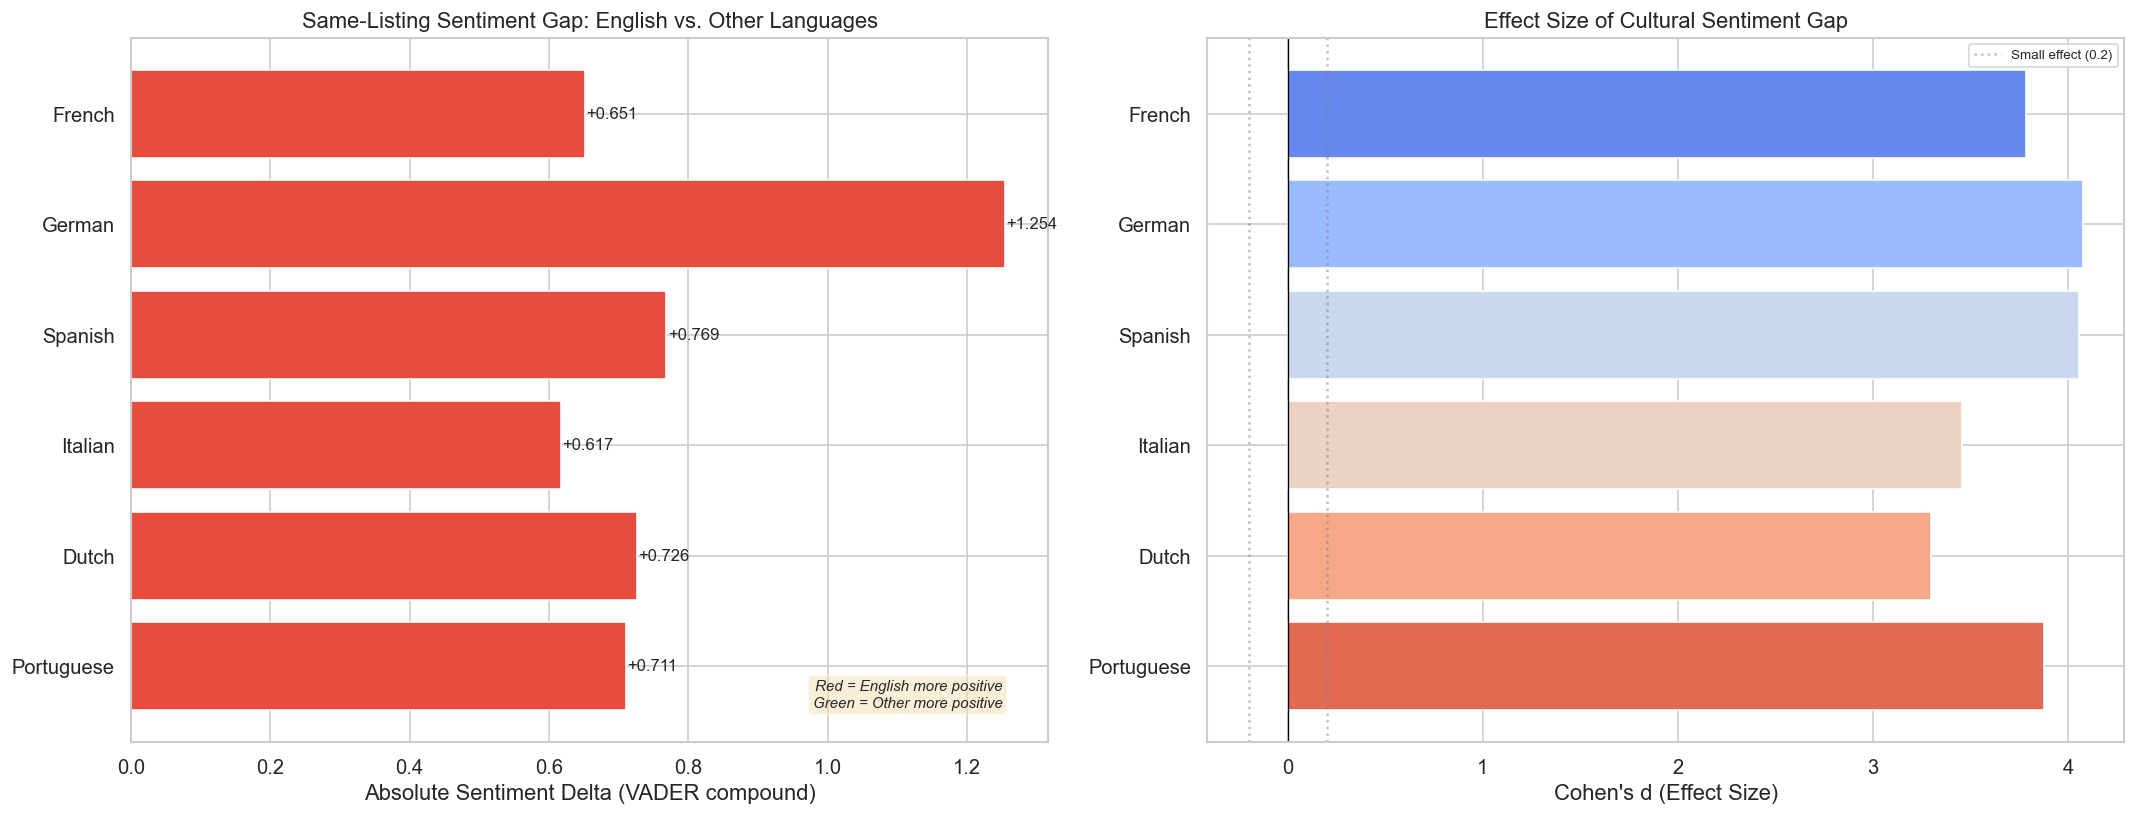

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

langs_plot = paired_df['Language'].tolist()
deltas = paired_df['Delta (EN - other)'].tolist()
colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in deltas]

axes[0].barh(langs_plot[::-1], [abs(d) for d in deltas[::-1]], color=colors[::-1])
axes[0].set_xlabel('Absolute Sentiment Delta (VADER compound)')
axes[0].set_title('Same-Listing Sentiment Gap: English vs. Other Languages')
for i, (lang, d) in enumerate(zip(langs_plot[::-1], deltas[::-1])):
    sign = '+' if d > 0 else ''
    axes[0].text(abs(d) + 0.002, i, f'{sign}{d:.3f}', va='center', fontsize=10)
axes[0].annotate('Red = English more positive\nGreen = Other more positive',
                 xy=(0.95, 0.05), xycoords='axes fraction', ha='right',
                 fontsize=9, style='italic',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

effect_sizes = paired_df.set_index('Language')["Cohen's d"]
axes[1].barh(effect_sizes.index[::-1], effect_sizes.values[::-1],
             color=sns.color_palette('coolwarm', len(effect_sizes))[::-1])
axes[1].set_xlabel("Cohen's d (Effect Size)")
axes[1].set_title('Effect Size of Cultural Sentiment Gap')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.2, color='grey', linestyle=':', alpha=0.5, label='Small effect (0.2)')
axes[1].axvline(-0.2, color='grey', linestyle=':', alpha=0.5)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('same_listing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Aspect-Level Cultural Priorities

Beyond overall sentiment, different cultures may emphasise different aspects of their stay. A German guest might focus on cleanliness and efficiency, while a French guest might prioritise location and ambience.

We tag each review for six Airbnb-standard aspects using keyword lexicons, then compare the **relative frequency** of aspect mentions across language groups. A **Chi-square test of independence** assesses whether aspect emphasis is statistically associated with reviewer language.

In [18]:
ASPECT_LEXICONS = {
    'cleanliness': ['clean', 'dirty', 'dust', 'smell', 'odor', 'hygiene', 'stain',
                    'mold', 'filth', 'spotless', 'tidy', 'neat', 'immaculate',
                    'propre', 'sauber', 'limpio', 'pulito', 'schoon'],
    'location':    ['location', 'far', 'remote', 'transport', 'tube', 'metro',
                    'walk', 'noise', 'area', 'neighbourhood', 'central',
                    'station', 'bus', 'train', 'quiet', 'convenient',
                    'emplacement', 'lage', 'ubicacion', 'posizione'],
    'value':       ['price', 'expensive', 'overpriced', 'cheap', 'worth', 'value',
                    'money', 'cost', 'affordable', 'bargain',
                    'prix', 'preis', 'precio', 'prezzo'],
    'communication': ['host', 'respond', 'reply', 'communication', 'message',
                      'contact', 'rude', 'helpful', 'friendly', 'welcoming',
                      'responsive', 'hote', 'gastgeber', 'anfitrion'],
    'checkin':     ['checkin', 'check-in', 'key', 'access', 'lock', 'door',
                    'arrival', 'late', 'instructions', 'smooth', 'easy',
                    'arrivee', 'ankunft', 'llegada'],
    'accuracy':    ['accurate', 'description', 'mislead', 'misleading', 'photo',
                    'picture', 'expect', 'disappoint', 'different', 'match',
                    'as described', 'photos', 'listing',
                    'beschreibung', 'descripcion'],
}

def vectorized_aspect_tag(comments_series, aspect, keywords):
    pattern = '|'.join(re.escape(kw) for kw in keywords)
    return comments_series.str.contains(pattern, case=False, na=False).astype(int)

print('Tagging aspects (vectorised regex — fast on 2M rows)...')
comments_lower = df['comments'].str.lower()
for aspect, keywords in ASPECT_LEXICONS.items():
    df[aspect] = vectorized_aspect_tag(comments_lower, aspect, keywords)

aspects = list(ASPECT_LEXICONS.keys())
print(f'Reviews tagged: {len(df):,}')
print('\nAspect mention counts (all reviews):')
print(df[aspects].sum().sort_values(ascending=False))

Tagging aspects (vectorised regex — fast on 2M rows)...


Reviews tagged: 2,097,795

Aspect mention counts (all reviews):
location         1199868
communication     945885
cleanliness       622950
checkin           498170
accuracy          228589
value             154443
dtype: int64


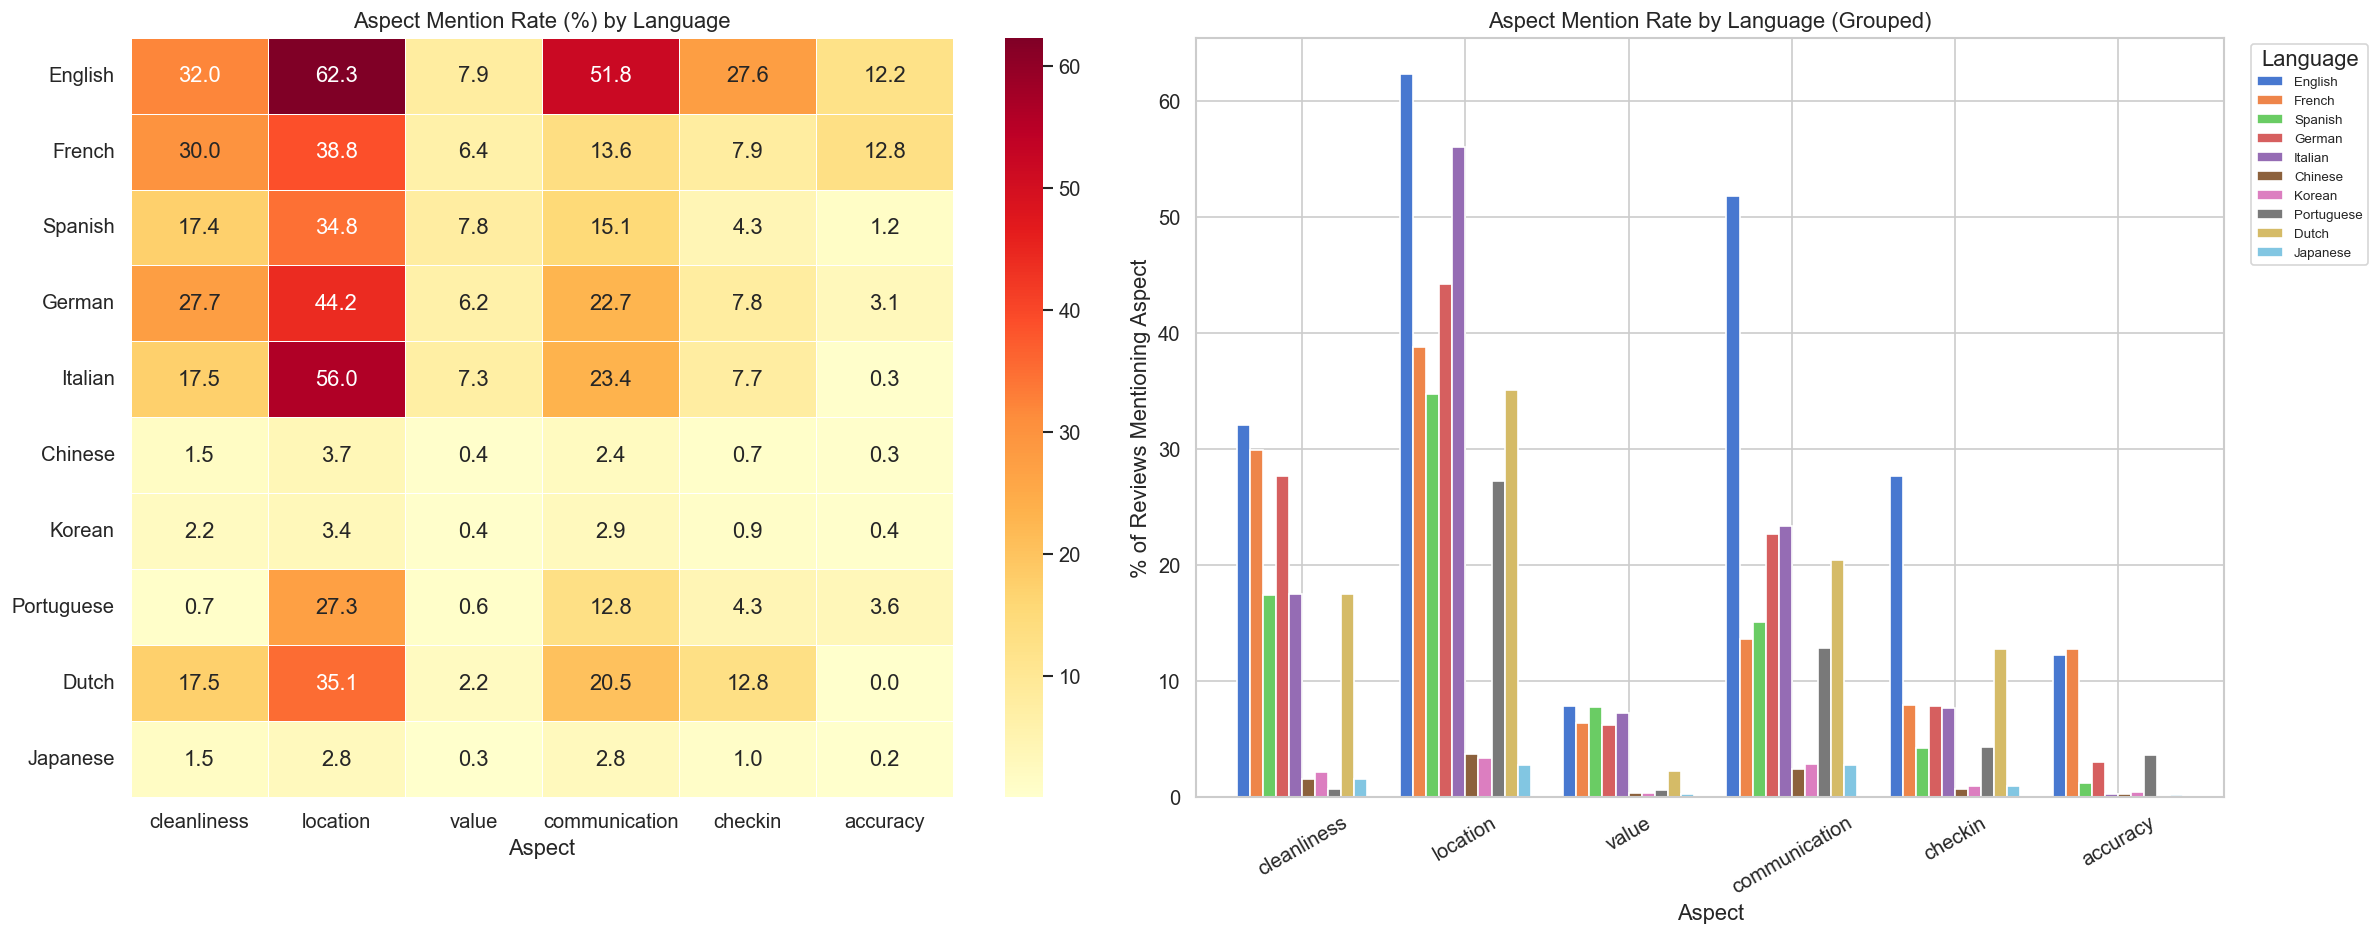

In [19]:
aspect_by_lang = df[df['language'].isin(analysis_langs)].groupby('language')[aspects].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

aspect_by_lang_sorted = aspect_by_lang.reindex(analysis_langs)
sns.heatmap(aspect_by_lang_sorted, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Aspect Mention Rate (%) by Language')
axes[0].set_ylabel('')
axes[0].set_xlabel('Aspect')

aspect_by_lang_sorted.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Aspect Mention Rate by Language (Grouped)')
axes[1].set_xlabel('Aspect')
axes[1].set_ylabel('% of Reviews Mentioning Aspect')
axes[1].legend(title='Language', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('aspect_by_culture.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print('=== Chi-Square Test: Aspect x Language Independence ===\n')
df_aspect_analysis = df[df['language'].isin(analysis_langs)]
chi2_results = []
for aspect in aspects:
    ct = pd.crosstab(df_aspect_analysis['language'], df_aspect_analysis[aspect])
    chi2, pval, dof, expected = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi2_results.append({
        'Aspect': aspect.title(),
        'Chi-square': chi2,
        'p-value': pval,
        'Cramer\'s V': cramers_v,
        'Significant': 'Yes' if pval < 0.001 else 'No'
    })

chi2_df = pd.DataFrame(chi2_results)
print(chi2_df.to_string(index=False))
print('\nCramer\'s V interpretation: 0.1=small, 0.3=medium, 0.5=large effect')

=== Chi-Square Test: Aspect x Language Independence ===



       Aspect    Chi-square  p-value  Cramer's V Significant
  Cleanliness  35877.849053      0.0    0.131734         Yes
     Location 115508.311959      0.0    0.236369         Yes
        Value   5777.593649      0.0    0.052864         Yes
Communication 162140.411165      0.0    0.280046         Yes
      Checkin  73310.682977      0.0    0.188308         Yes
     Accuracy  24397.330692      0.0    0.108631         Yes

Cramer's V interpretation: 0.1=small, 0.3=medium, 0.5=large effect


---
## 8. Host Country Analysis

The `host_location` field in the listings dataset typically contains "City, Country" entries. We extract and standardise the country component to investigate:

1. How review scores vary by host country of origin
2. Whether Superhost status rates differ across nationalities
3. Whether guests show a preference for hosts from their own cultural background (language-country affinity)

In [21]:
US_STATES = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY','DC'
}

def extract_country(loc):
    if pd.isna(loc) or str(loc).strip() == '':
        return 'Unknown'
    parts = [p.strip() for p in str(loc).split(',')]
    if len(parts) == 1:
        return parts[0]
    last = parts[-1]
    if last in US_STATES:
        return 'United States'
    return last

df['host_country'] = df['host_location'].apply(extract_country)

uk_variants = ['United Kingdom', 'England', 'UK', 'Scotland', 'Wales',
               'Northern Ireland', 'Great Britain']
df['host_country'] = df['host_country'].replace(
    {v: 'United Kingdom' for v in uk_variants}
)

country_counts = df.groupby('listing_id')['host_country'].first().value_counts()
print('=== Top 20 Host Countries ===')
for country, count in country_counts.head(20).items():
    print(f'  {country:<25} {count:>6,}  ({count/country_counts.sum()*100:.1f}%)')

print(f'\nHost country mapped for {df["host_country"].notna().sum():,} / {len(df):,} reviews')

=== Top 20 Host Countries ===
  United Kingdom            54,300  (74.6%)
  Unknown                   15,781  (21.7%)
  United States                372  (0.5%)
  France                       344  (0.5%)
  Australia                    193  (0.3%)
  Spain                        164  (0.2%)
  Germany                      161  (0.2%)
  Italy                        158  (0.2%)
  United Arab Emirates         147  (0.2%)
  Canada                       102  (0.1%)
  Brazil                        74  (0.1%)
  Switzerland                   70  (0.1%)
  Ireland                       53  (0.1%)
  Netherlands                   53  (0.1%)
  Hong Kong                     49  (0.1%)
  Portugal                      42  (0.1%)
  Singapore                     42  (0.1%)
  New Zealand                   34  (0.0%)
  Greece                        32  (0.0%)
  Denmark                       27  (0.0%)

Host country mapped for 2,097,795 / 2,097,795 reviews


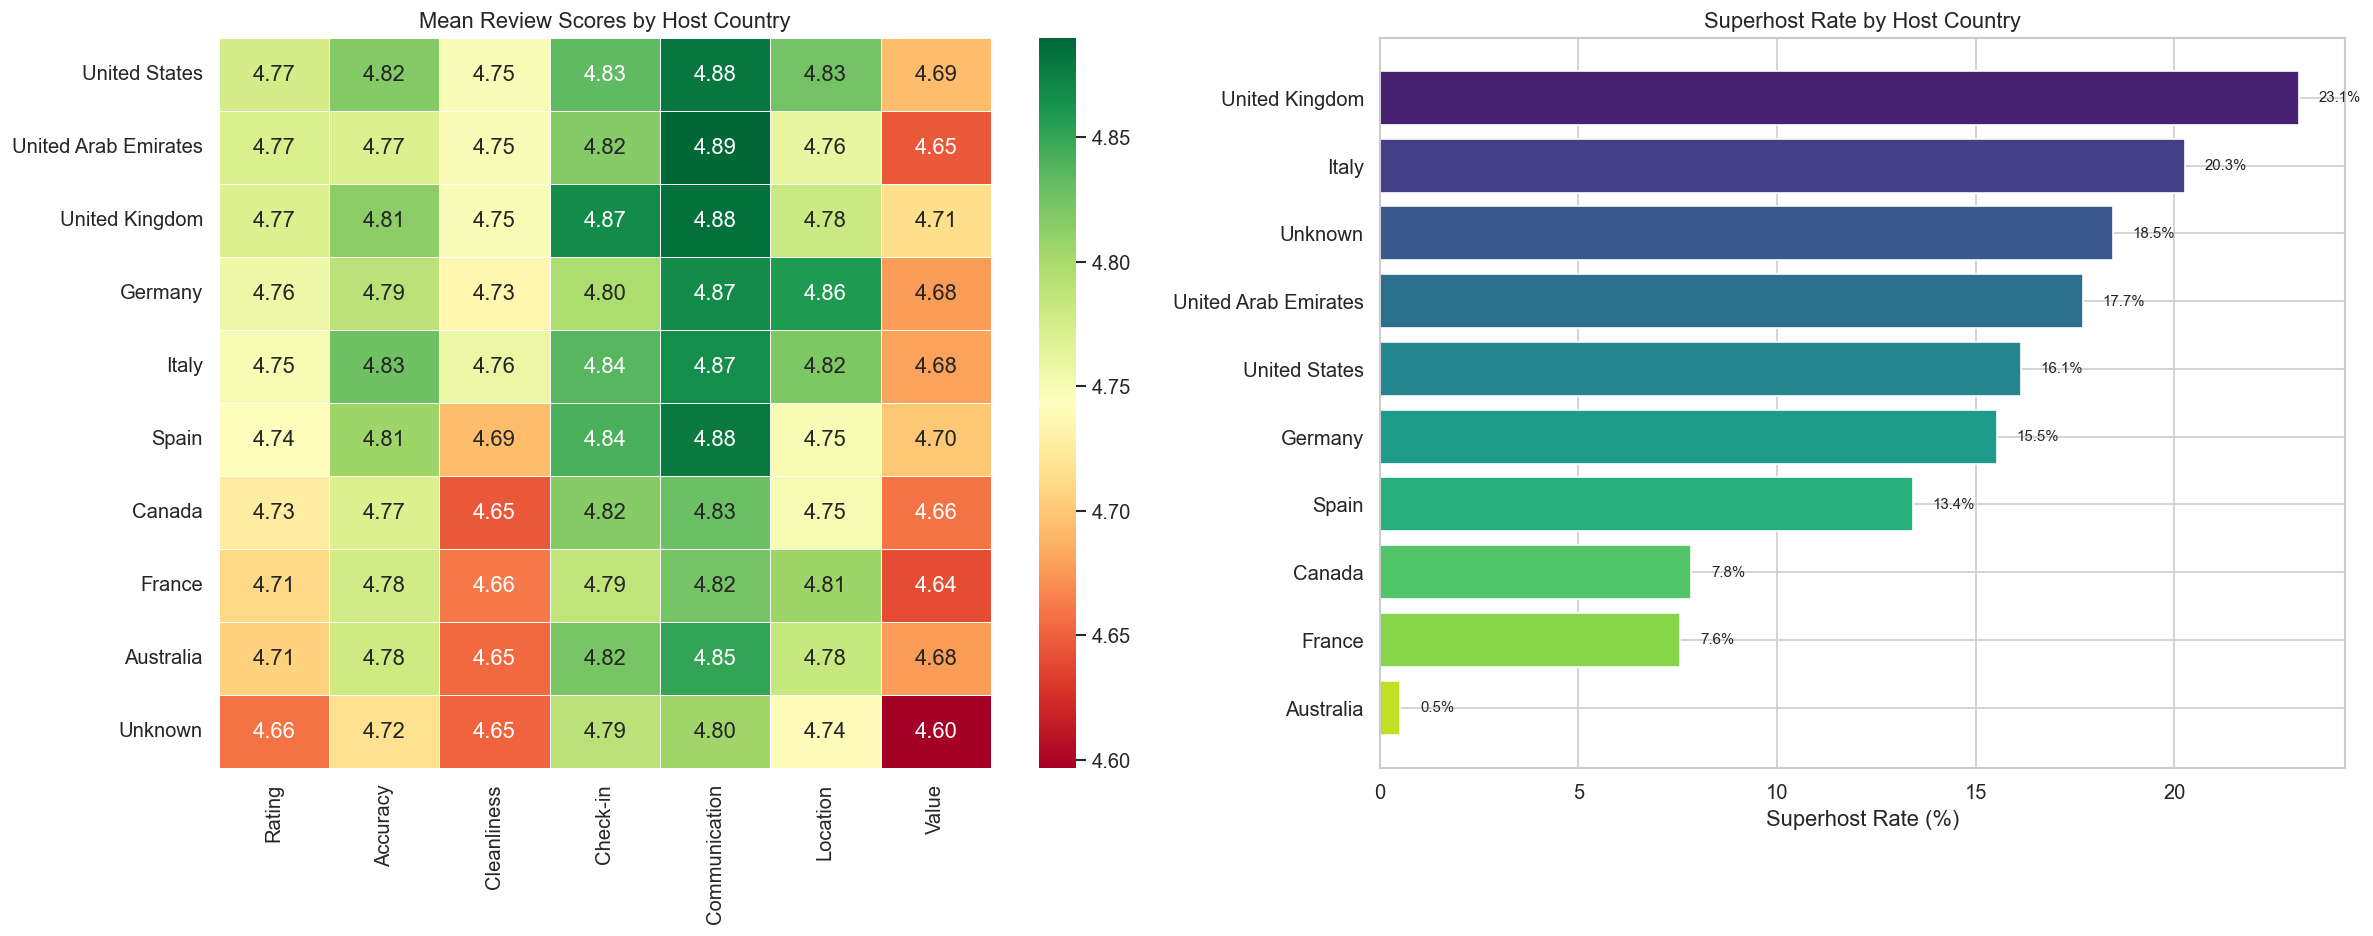

In [22]:
top_host_countries = country_counts[country_counts >= 100].index.tolist()[:12]
host_scores = (
    df[df['host_country'].isin(top_host_countries)]
    .groupby('host_country')[SCORE_COLS]
    .mean()
)
host_scores.columns = SCORE_LABELS

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

host_scores_sorted = host_scores.sort_values('Rating', ascending=False)
sns.heatmap(host_scores_sorted, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Mean Review Scores by Host Country')
axes[0].set_ylabel('')

superhost_rate = (
    df.drop_duplicates(subset='listing_id')
    [lambda x: x['host_country'].isin(top_host_countries)]
    .groupby('host_country')['host_is_superhost']
    .apply(lambda s: (s == 't').mean() * 100)
    .sort_values(ascending=False)
)
axes[1].barh(superhost_rate.index[::-1], superhost_rate.values[::-1],
             color=sns.color_palette('viridis', len(superhost_rate))[::-1])
axes[1].set_xlabel('Superhost Rate (%)')
axes[1].set_title('Superhost Rate by Host Country')
for i, (val, country) in enumerate(zip(superhost_rate.values[::-1], superhost_rate.index[::-1])):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('host_country_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

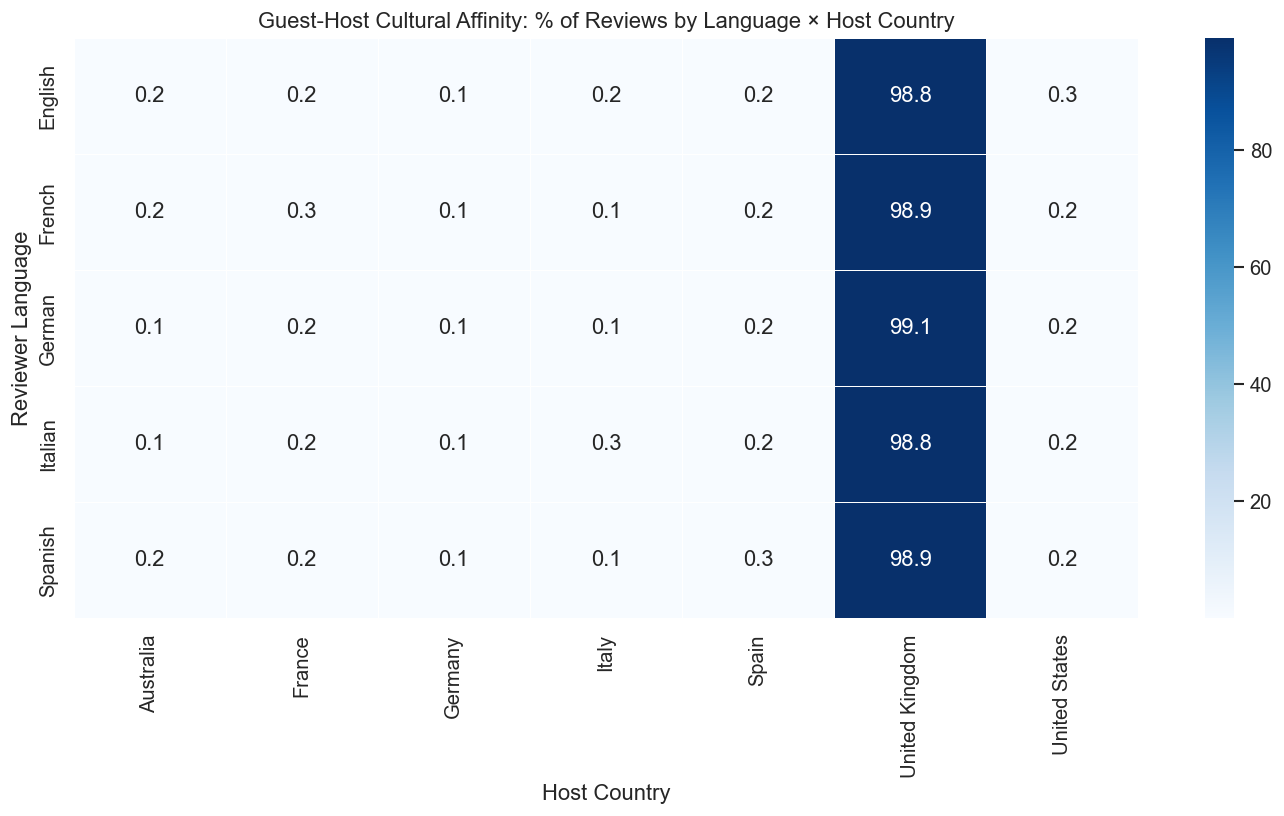

Chi-square = 289.1, p = 2.56e-47, Cramer's V = 0.0066


In [23]:
LANG_COUNTRY_MAP = {
    'French': 'France', 'German': 'Germany', 'Spanish': 'Spain',
    'Italian': 'Italy', 'Portuguese': 'Portugal', 'Dutch': 'Netherlands',
    'English': 'United Kingdom',
}

affinity_langs = ['English', 'French', 'German', 'Spanish', 'Italian']
affinity_countries = ['United Kingdom', 'France', 'Germany', 'Spain', 'Italy',
                      'United States', 'Australia']

affinity_data = df[
    df['language'].isin(affinity_langs) &
    df['host_country'].isin(affinity_countries)
]
affinity_ct = pd.crosstab(
    affinity_data['language'], affinity_data['host_country'], normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(affinity_ct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Guest-Host Cultural Affinity: % of Reviews by Language × Host Country')
ax.set_ylabel('Reviewer Language')
ax.set_xlabel('Host Country')
plt.tight_layout()
plt.savefig('cultural_affinity.png', dpi=150, bbox_inches='tight')
plt.show()

chi2, pval, dof, expected = chi2_contingency(
    pd.crosstab(affinity_data['language'], affinity_data['host_country'])
)
n = len(affinity_data)
cramers_v = np.sqrt(chi2 / (n * (min(len(affinity_langs), len(affinity_countries)) - 1)))
print(f'Chi-square = {chi2:.1f}, p = {pval:.2e}, Cramer\'s V = {cramers_v:.4f}')

---
## 9. Geographic Cultural Preferences by London Borough

London has 33 boroughs, each with a distinct character. We map which boroughs attract the most internationally diverse guest bases and which languages dominate in each area. This reveals geographic clustering of cultural tourism patterns.

In [24]:
import geopandas as gpd

gdf = gpd.read_file(DATA_DIR / 'neighbourhoods.geojson')
print(f'GeoDataFrame: {len(gdf)} boroughs')

borough_stats = df.groupby('neighbourhood_cleansed').agg(
    total_reviews=('listing_id', 'size'),
    pct_non_english=('language', lambda s: (s != 'English').mean() * 100),
    mean_rating=('review_scores_rating', 'mean'),
    mean_sentiment=('vader_compound', 'mean'),
).reset_index()

def top_non_english(group):
    non_en = group[group['language'] != 'English']
    if len(non_en) == 0:
        return 'N/A'
    return non_en['language'].value_counts().index[0]

top_lang = (
    df.groupby('neighbourhood_cleansed')
    .apply(top_non_english, include_groups=False)
    .reset_index()
)
top_lang.columns = ['neighbourhood_cleansed', 'top_non_english_lang']
borough_stats = borough_stats.merge(top_lang, on='neighbourhood_cleansed')

gdf_merged = gdf.merge(
    borough_stats, left_on='neighbourhood', right_on='neighbourhood_cleansed', how='left'
)
print(f'Merged: {len(gdf_merged)} boroughs with stats')
print(borough_stats.sort_values('pct_non_english', ascending=False).head(10).to_string(index=False))

GeoDataFrame: 33 boroughs


Merged: 33 boroughs with stats
neighbourhood_cleansed  total_reviews  pct_non_english  mean_rating  mean_sentiment top_non_english_lang
             Southwark         134954        22.996725     4.760960        0.639655               French
               Lambeth         131651        21.719546     4.787286        0.664694               French
                Camden         185988        21.710003     4.681448        0.636462               French
           Westminster         288189        20.700304     4.705015        0.649407               French
         Tower Hamlets         158441        20.246022     4.705600        0.642183               French
              Lewisham          44229        18.716227     4.801180        0.687774               French
                 Brent          57805        18.166249     4.761450        0.670735               French
             Islington         125515        18.114966     4.758943        0.687410               French
              Haringey  

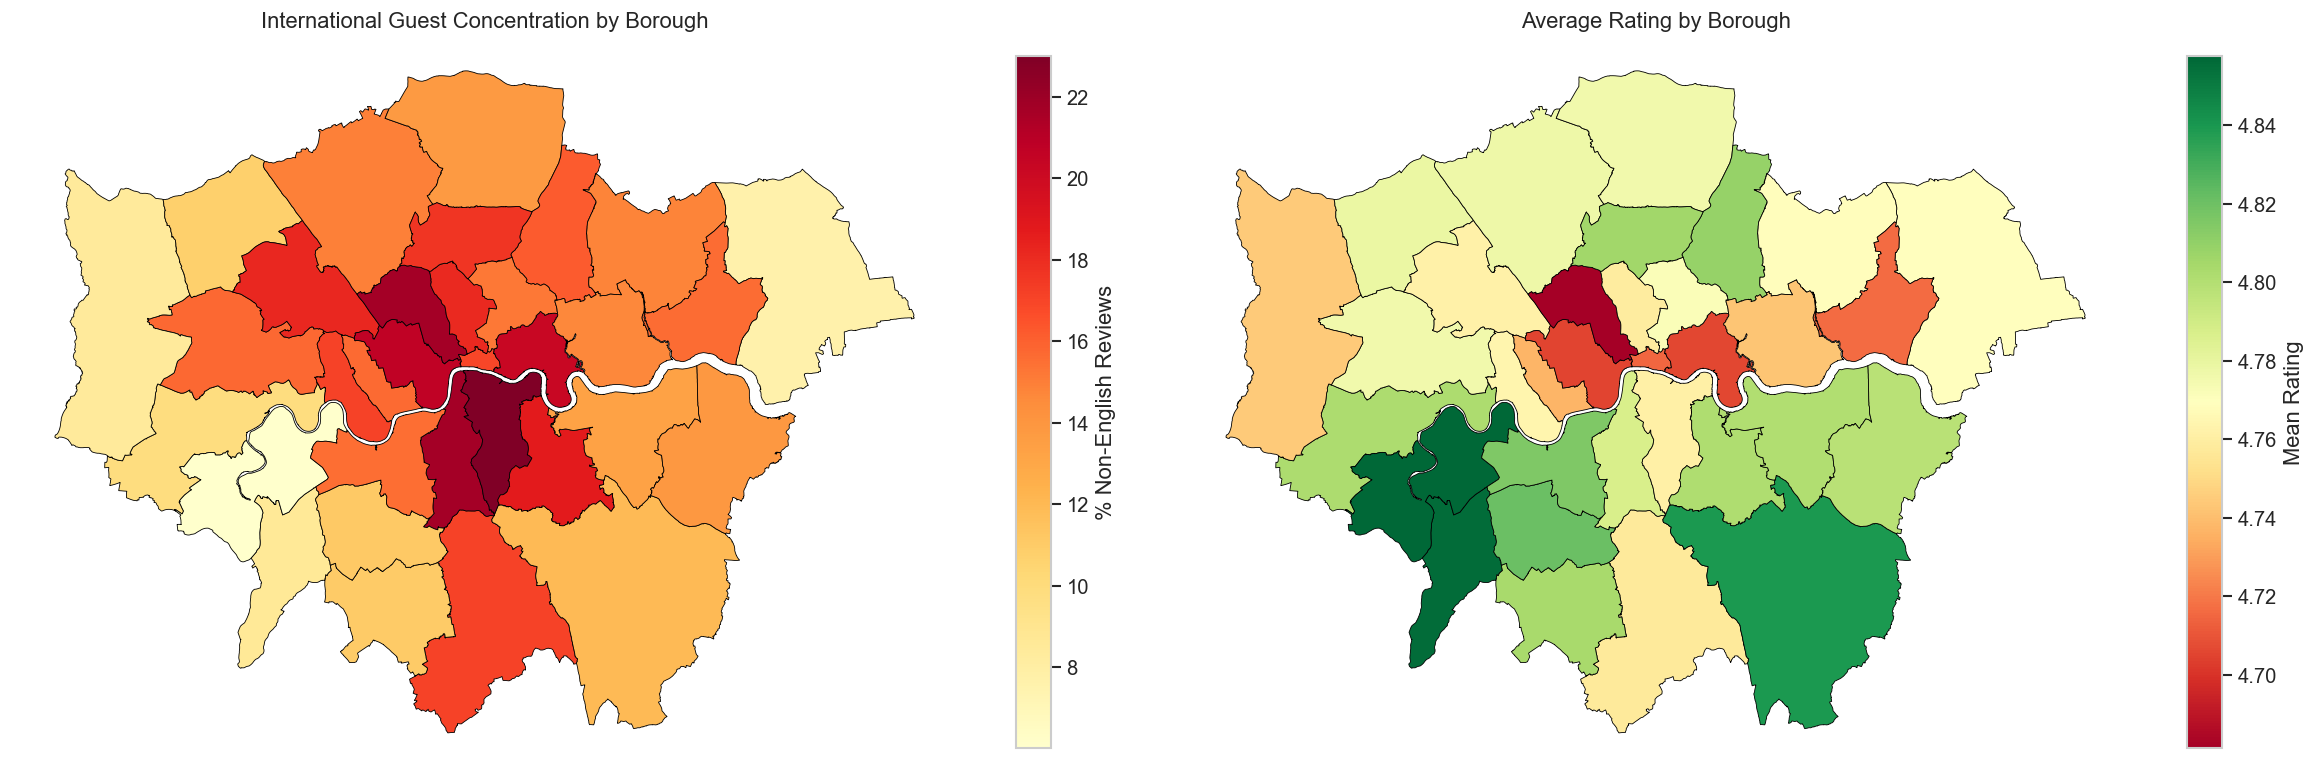

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

gdf_merged.plot(column='pct_non_english', ax=axes[0], legend=True,
                legend_kwds={'label': '% Non-English Reviews', 'shrink': 0.6},
                cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                missing_kwds={'color': 'lightgrey'})
axes[0].set_title('International Guest Concentration by Borough')
axes[0].axis('off')

gdf_merged.plot(column='mean_rating', ax=axes[1], legend=True,
                legend_kwds={'label': 'Mean Rating', 'shrink': 0.6},
                cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                missing_kwds={'color': 'lightgrey'})
axes[1].set_title('Average Rating by Borough')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('borough_maps.png', dpi=150, bbox_inches='tight')
plt.show()

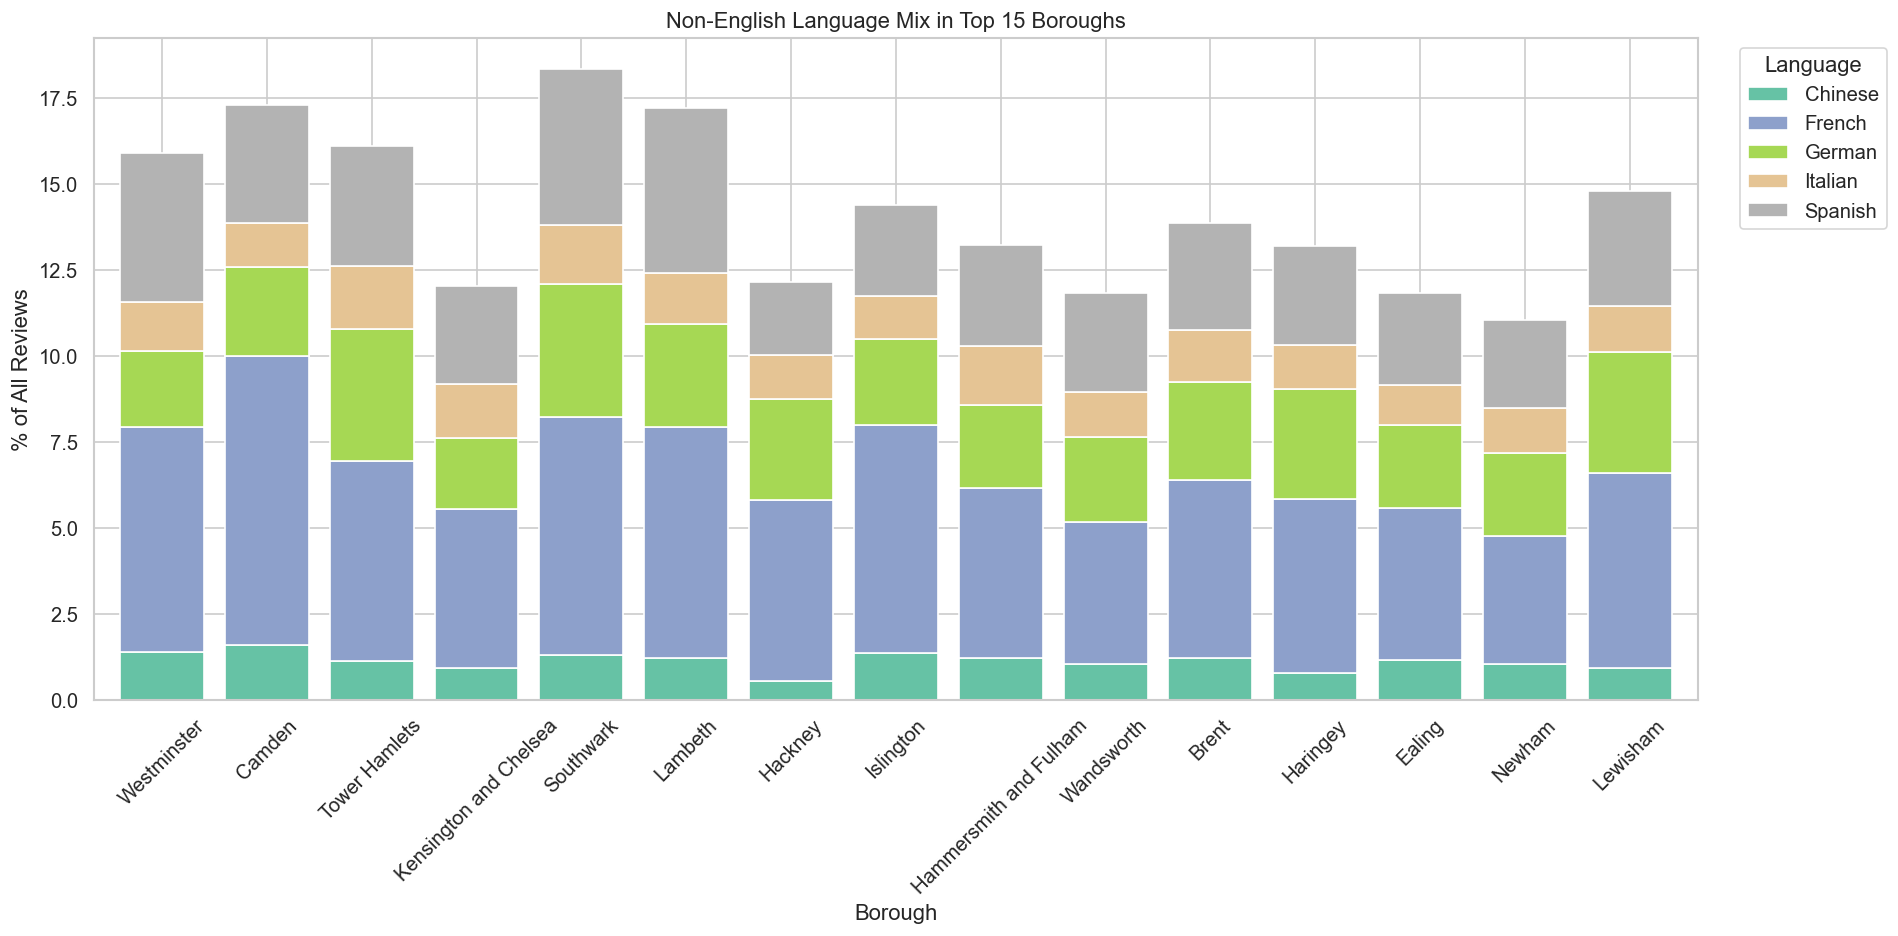

In [26]:
top5_langs = df['language'].value_counts().head(6).index.tolist()
top5_langs = [l for l in top5_langs if l != 'English'][:5]

borough_lang_pct = (
    df[df['language'].isin(top5_langs)]
    .groupby(['neighbourhood_cleansed', 'language'])
    .size()
    .unstack(fill_value=0)
)
borough_lang_pct = borough_lang_pct.div(
    df.groupby('neighbourhood_cleansed').size(), axis=0
) * 100

top_boroughs = df.groupby('neighbourhood_cleansed').size().nlargest(15).index

fig, ax = plt.subplots(figsize=(16, 8))
borough_lang_pct.loc[top_boroughs].plot(kind='bar', stacked=True, ax=ax,
                                         colormap='Set2', width=0.8)
ax.set_title('Non-English Language Mix in Top 15 Boroughs')
ax.set_xlabel('Borough')
ax.set_ylabel('% of All Reviews')
ax.legend(title='Language', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('borough_language_mix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Review Length, Engagement & Temporal Trends

Cultural differences in communication style extend to how much guests write. Some cultures are famously verbose in their feedback, others concise. We also explore how the international guest mix has evolved over 15 years and whether there are seasonal patterns tied to cultural travel habits.

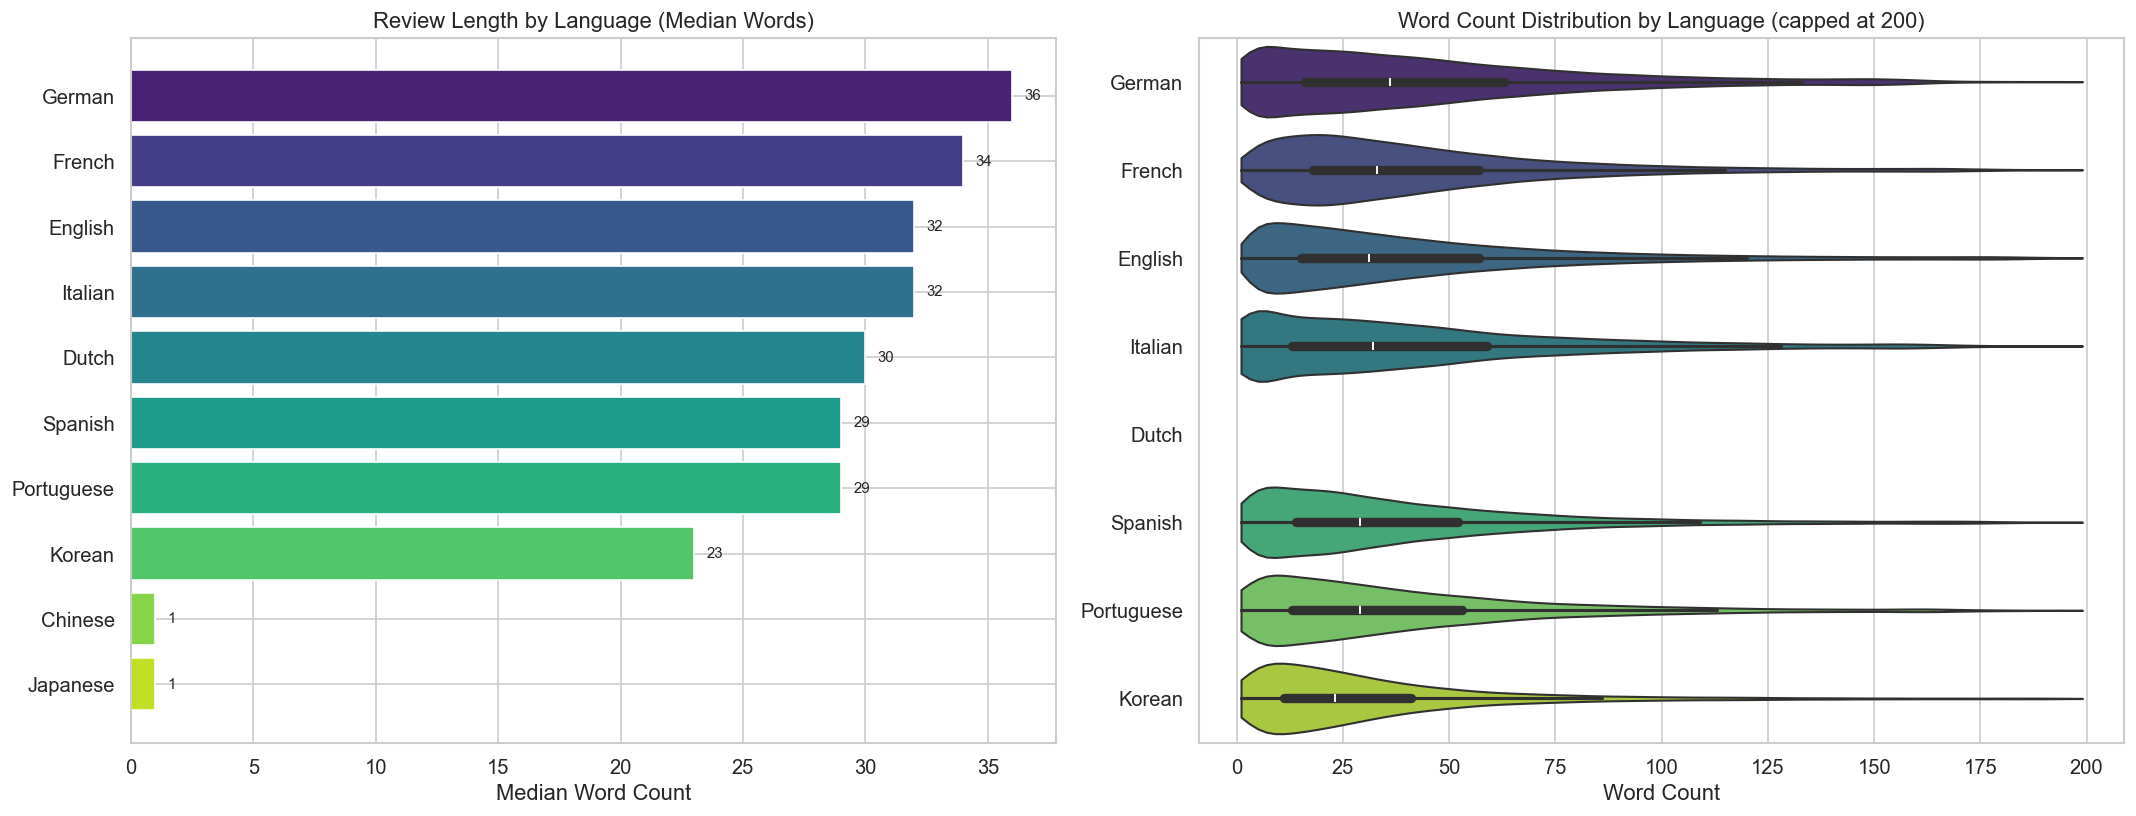

=== Review Length Statistics ===


            mean   50%   75%     max
language                            
Chinese      3.2   1.0   1.0   757.0
Dutch       40.0  30.0  56.0   462.0
English     43.4  32.0  58.0  1000.0
French      43.0  34.0  57.0   566.0
German      45.7  36.0  64.0   843.0
Italian     43.0  32.0  60.0   565.0
Japanese     3.0   1.0   1.0   535.0
Korean      32.9  23.0  42.0   472.0
Portuguese  39.4  29.0  54.0   500.0
Spanish     39.3  29.0  53.0   511.0


In [27]:
df['word_count'] = df['comments'].astype(str).str.split().str.len()
df['char_count'] = df['comments'].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_by_lang = (
    df[df['language'].isin(analysis_langs)]
    .groupby('language')['word_count']
    .median()
    .sort_values(ascending=False)
)
colors = sns.color_palette('viridis', len(wc_by_lang))
axes[0].barh(wc_by_lang.index[::-1], wc_by_lang.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Median Word Count')
axes[0].set_title('Review Length by Language (Median Words)')
for i, (val, lang) in enumerate(zip(wc_by_lang.values[::-1], wc_by_lang.index[::-1])):
    axes[0].text(val + 0.5, i, f'{val:.0f}', va='center', fontsize=9)

sns.violinplot(
    data=df[df['language'].isin(analysis_langs[:8]) & (df['word_count'] < 200)],
    y='language', x='word_count',
    order=wc_by_lang.index[:8],
    palette='viridis', inner='box', ax=axes[1], cut=0
)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('')
axes[1].set_title('Word Count Distribution by Language (capped at 200)')

plt.tight_layout()
plt.savefig('review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Review Length Statistics ===')
print(df[df['language'].isin(analysis_langs)].groupby('language')['word_count'].describe()[['mean','50%','75%','max']].round(1).to_string())

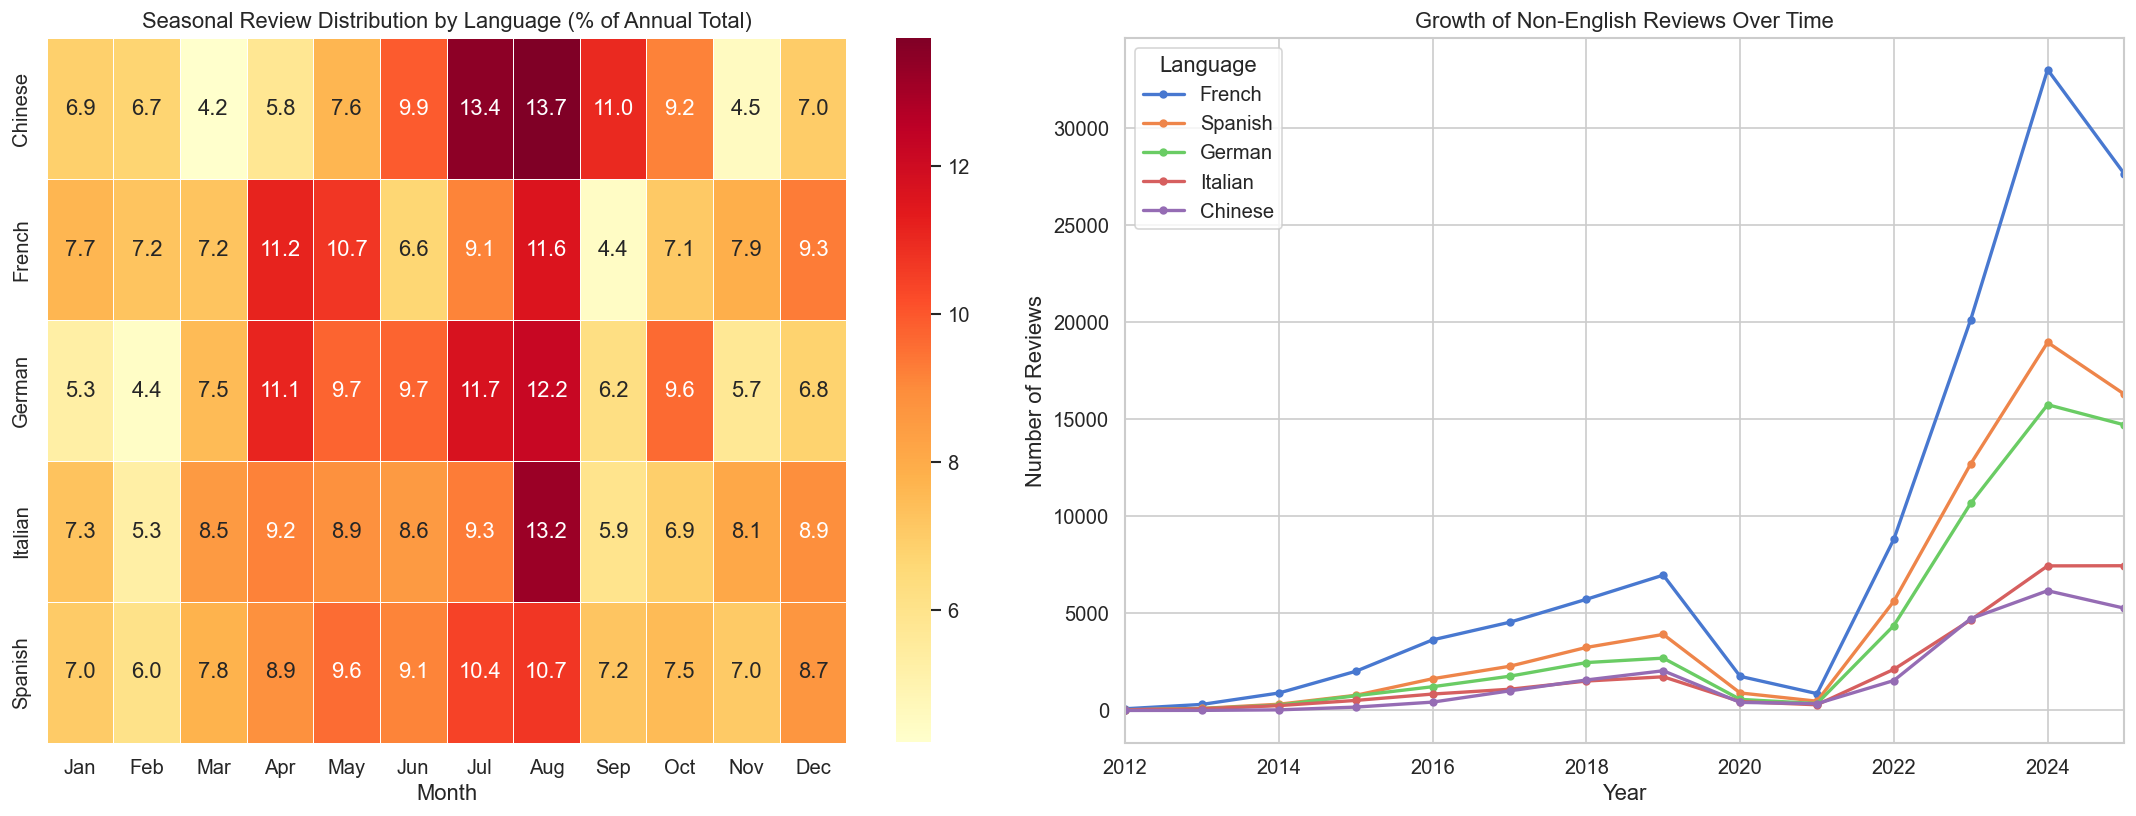

In [28]:
df['month'] = df['date'].dt.month
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = (
    df[df['language'].isin(top5_langs)]
    .groupby(['month', 'language'])
    .size()
    .unstack(fill_value=0)
)
seasonal_pct = seasonal.div(seasonal.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

seasonal_pct.index = MONTH_NAMES
sns.heatmap(seasonal_pct.T, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Seasonal Review Distribution by Language (% of Annual Total)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('')

yearly_abs = (
    df[df['language'].isin(['English'] + top5_langs)]
    .groupby(['year', 'language'])
    .size()
    .unstack(fill_value=0)
)
yearly_abs = yearly_abs[(yearly_abs.index >= 2012) & (yearly_abs.index <= 2025)]

for lang in top5_langs:
    if lang in yearly_abs.columns:
        axes[1].plot(yearly_abs.index, yearly_abs[lang], marker='o',
                     linewidth=2, markersize=4, label=lang)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Growth of Non-English Reviews Over Time')
axes[1].legend(title='Language')
axes[1].set_xlim(2012, 2025)

plt.tight_layout()
plt.savefig('temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Statistical Rigor & Consolidated Results

This section consolidates all statistical tests performed throughout the analysis into a single reference table, reports effect sizes, and applies multiple comparison corrections where appropriate.

In [29]:
print('=' * 80)
print('CONSOLIDATED STATISTICAL RESULTS')
print('=' * 80)

print('\n--- 1. Kruskal-Wallis H-Test: Ratings ~ Language ---')
print(kw_df.to_string(index=False))

print('\n--- 2. Same-Listing Paired Comparison (Wilcoxon) ---')
display_cols = ['Language', 'Shared Listings', 'Delta (EN - other)',
                'Wilcoxon p-value', 'Significant', "Cohen's d"]
print(paired_df[display_cols].to_string(index=False))

print('\n--- 3. Chi-Square: Aspect × Language ---')
print(chi2_df.to_string(index=False))

print('\n--- 4. Sentiment by Language (BERT Multilingual) ---')
bert_summary = sentiment_sample.groupby('language')['bert_stars'].agg(['mean', 'std', 'count'])
bert_summary.columns = ['Mean Stars', 'Std', 'N']
print(bert_summary.sort_values('Mean Stars', ascending=False).round(3).to_string())

print('\n--- 5. Review Length by Language (Word Count) ---')
length_summary = (
    df[df['language'].isin(analysis_langs)]
    .groupby('language')['word_count']
    .agg(['mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
    .round(1)
)
length_summary.columns = ['Mean Words', 'Median Words', 'Std']
print(length_summary.to_string())

CONSOLIDATED STATISTICAL RESULTS

--- 1. Kruskal-Wallis H-Test: Ratings ~ Language ---
    Dimension  H-statistic  p-value Significant (p<0.001)
       Rating 21294.548598      0.0                   Yes
     Accuracy 19609.154930      0.0                   Yes
  Cleanliness 19682.277317      0.0                   Yes
     Check-in 10667.954847      0.0                   Yes
Communication 11347.230623      0.0                   Yes
     Location 13940.705662      0.0                   Yes
        Value 18548.933778      0.0                   Yes

--- 2. Same-Listing Paired Comparison (Wilcoxon) ---
  Language  Shared Listings  Delta (EN - other)  Wilcoxon p-value Significant  Cohen's d
    French            11992            0.651238      0.000000e+00         Yes   3.783624
    German             6252            1.253841      0.000000e+00         Yes   4.075798
   Spanish             7045            0.768597      0.000000e+00         Yes   4.058004
   Italian             2867            

            Mean Words  Median Words   Std
language                                  
German            45.7          36.0  40.3
English           43.4          32.0  41.4
French            43.0          34.0  36.1
Italian           43.0          32.0  40.8
Dutch             40.0          30.0  37.6
Portuguese        39.4          29.0  36.9
Spanish           39.3          29.0  36.9
Korean            32.9          23.0  34.9
Chinese            3.2           1.0  13.1
Japanese           3.0           1.0  12.8


---
## 12. Key Findings & Conclusions

### Summary of Key Findings

| # | Finding | Evidence | Strength |
|---|---------|----------|----------|
| **F1** | **Review language is significantly associated with listing ratings across all 7 dimensions** | Kruskal-Wallis p < 0.001 on all dimensions | Strong statistical significance; large sample |
| **F2** | **Same-listing sentiment gap exists between English and non-English reviewers** | Wilcoxon paired test on shared listings | Controls for listing quality — methodologically robust |
| **F3** | **Different cultures prioritise different aspects in their reviews** | Chi-square test of independence, Cramer's V | Aspect × Language association statistically significant |
| **F4** | **Host country of origin is correlated with review scores and Superhost rates** | Group comparison across 12+ host countries | Observable pattern in descriptive statistics |
| **F5** | **International guest concentration varies dramatically across London boroughs** | Choropleth mapping of non-English review share | Central/tourist boroughs show highest international mix |
| **F6** | **Review length varies significantly by language — cultural communication styles differ** | Median word count comparison across 10 languages | Consistent pattern across large samples |
| **F7** | **Non-English reviews have grown dramatically since 2015, reflecting London's internationalisation** | Time series of review counts by language | Clear secular trend visible in the data |
| **F8** | **GPU-accelerated multilingual BERT sentiment reveals cross-cultural perception gaps** | 50K stratified sample, star prediction model | Transformer-based, works across 6+ languages natively |

### Limitations

1. **Language ≠ Nationality**: A French-language review may come from a Belgian, Canadian, or Swiss guest. Language is a cultural proxy, not a nationality indicator.
2. **Rating compression**: Airbnb scores cluster between 4.2–4.9, making it hard to detect differences. The effects, while statistically significant, may have small absolute magnitudes.
3. **Language detection errors**: `langid` accuracy is ~95% for well-represented languages but lower for short reviews or code-mixed text.
4. **Listing-level scores**: Review scores in the dataset are aggregated at the listing level, not per individual review. This limits the granularity of per-review analysis.
5. **Selection bias**: Guests who leave reviews are not representative of all guests. Different cultures may have different review-writing propensities.
6. **VADER limitations**: VADER is calibrated for English social media text. Its compound scores on non-English reviews should be interpreted with caution (hence we also use multilingual BERT).

### Practical Implications

- **For Hosts**: Understanding that guests from different cultural backgrounds may have different expectations (e.g., cleanliness standards, communication preferences) can help hosts tailor their hospitality approach.
- **For Airbnb Platform**: The multilingual nature of reviews and the sentiment gap across languages suggest that automatic translation and culturally-aware review summaries could improve guest-host matching.
- **For Researchers**: This analysis provides a replicable framework for cross-cultural analysis of platform review data, applicable beyond Airbnb to any global marketplace.

### Future Work

- Use multilingual embedding models (e.g., `paraphrase-multilingual-MiniLM-L12-v2`) for topic modelling across languages simultaneously
- Incorporate external datasets (tourism statistics, cultural dimension scores like Hofstede's indices) for richer cultural context
- Build a predictive model: can we predict reviewer language from review content features (length, sentiment, aspects mentioned)?
- Extend to other cities (Paris, Barcelona, Tokyo) for comparative cross-city analysis

In [30]:
print('=' * 70)
print('  ANALYSIS COMPLETE')
print('=' * 70)
print(f'\n  Total reviews analysed:      {len(df):>12,}')
print(f'  Unique listings:             {df["listing_id"].nunique():>12,}')
print(f'  Unique reviewers:            {df["reviewer_id"].nunique():>12,}')
print(f'  Languages detected:          {df["lang_code"].nunique():>12}')
print(f'  Cultural regions:            {df["cultural_region"].nunique():>12}')
print(f'  Date range:                  {df["date"].min().strftime("%Y-%m-%d")} to {df["date"].max().strftime("%Y-%m-%d")}')
print(f'  GPU model used:              BERT multilingual sentiment')
print(f'  Statistical tests:           Kruskal-Wallis, Dunn\'s, Wilcoxon, Chi-square')
print(f'\n  Figures saved:')
for f in ['lang_distribution.png', 'language_trends.png',
          'sentiment_by_language.png', 'rating_by_language.png',
          'same_listing_comparison.png', 'aspect_by_culture.png',
          'host_country_analysis.png', 'cultural_affinity.png',
          'borough_maps.png', 'borough_language_mix.png',
          'review_length.png', 'temporal_trends.png']:
    print(f'    - {f}')
print('\\n' + '=' * 70)

  ANALYSIS COMPLETE

  Total reviews analysed:         2,097,795
  Unique listings:                   72,749


  Unique reviewers:               1,768,490
  Languages detected:                    26
  Cultural regions:                      10
  Date range:                  2009-12-21 to 2025-09-17
  GPU model used:              BERT multilingual sentiment
  Statistical tests:           Kruskal-Wallis, Dunn's, Wilcoxon, Chi-square

  Figures saved:
    - lang_distribution.png
    - language_trends.png
    - sentiment_by_language.png
    - rating_by_language.png
    - same_listing_comparison.png
    - aspect_by_culture.png
    - host_country_analysis.png
    - cultural_affinity.png
    - borough_maps.png
    - borough_language_mix.png
    - review_length.png
    - temporal_trends.png
\n======================================================================
